# Explore mcmc results, create dataframes and plots for analysis.

In [1]:
import sys
sys.path.append("../code")

In [2]:
from config import get_Extra, load_data
import pints
import pints.io
import pints.plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import glob
import matplotlib.gridspec as gridspec
from scipy.stats import skew
from scipy.stats import mode
import seaborn as sns
import pickle
import scipy.stats as stats

Some utilities:

In [3]:
# function for making and stacking trace plots:


def trace_plot_custom(axs_row, plt_samples, burn_in, initial_guess, param_name):
    """
    Plots histogram and trace on provided axs_row (2 axes: hist on right, trace on left).
    plt_samples include full chains, histogram is made from samples after burn_in.
    """
    chains, iters = plt_samples.shape

    # Plot posterior histogram on left
    for i in range(chains):
        axs_row[0].hist(plt_samples[i, burn_in:], bins=40, density=False, alpha=0.6, label=f'Chain {i+1}')

    flat = plt_samples[:, burn_in:].flatten()
    mean_val = np.mean(flat)
    median_val = np.median(flat)

    axs_row[0].axvline(mean_val, color='r', linestyle='--', label=f'MCMC mean {mean_val:.3f}')
    axs_row[0].axvline(median_val, color='r', label=f'MCMC median {median_val:.3f}')
    axs_row[0].axvline(initial_guess, color='b', linestyle='--', label=f'Initial guess {initial_guess:.3f}')
    axs_row[0].set_xlabel(param_name)
    axs_row[0].set_ylabel('Counts after burn-in')
    axs_row[0].legend(loc='best')


    # Plot trace on right
    for c in range(chains):
        axs_row[1].plot(plt_samples[c, :], alpha=0.8, label=f'Chain {c+1}')
    axs_row[1].axvline(x=burn_in, color='grey', linestyle='--')
    axs_row[1].legend(loc='best')
    axs_row[1].set_xlabel('Iterations')
    axs_row[1].set_ylabel(param_name)
    


def plot_multiple_traces(all_samples, burn_in, initial_guesses, param_names):
    """
    all_samples: list of np.arrays of shape (chains, iterations, n_params)
    initial_guesses: list of float initial guesses
    param_names: list of param names (str)
    """
    if all_samples.ndim == 2:
        # If all_samples is 2D, assume it's a single  parameter with multiple chains:
        all_samples = np.expand_dims(all_samples, axis=-1)

    chains, iters, n_params = all_samples.shape

    with sns.plotting_context('talk'):
        fig, axs = plt.subplots(nrows=n_params, ncols=2, figsize=(20, 5 * n_params), constrained_layout=True)

        if n_params == 1:
            trace_plot_custom(axs, all_samples, burn_in, initial_guesses, param_names)
        else:
            # If multiple parameters, iterate over axs and all_samples:
            for i in range(n_params):
                trace_plot_custom(axs[i], all_samples[:, :, i], burn_in, initial_guesses[i], param_names[i])



# trace plot function from PINTS:
def trace_plot(plt_samples, burn_in, initial_guess, param_name):
    f,axs = pints.plot.trace(plt_samples[:, :, :], parameter_names=[param_name])
    f.set_figheight(5)
    axs[0][0].axvline(x=plt_samples[:, burn_in:, :].mean(), color='r', linestyle='--', label='mcmc mean '+str(np.round(plt_samples[:, burn_in:, :].mean(),3)))
    axs[0][0].axvline(x=np.median(plt_samples[:, burn_in:, :]), color='r', label='mcmc median '+str(np.round(np.median(plt_samples[:, burn_in:, :]),3)))
    axs[0][0].axvline(x=mode(plt_samples[:, burn_in:, :],axis=None)[0], linestyle=':', color='r', label='mcmc mode ' + str(np.round(mode(plt_samples[:, burn_in:, :],axis=None)[0],3)))
    axs[0][0].axvline(x=initial_guess, color='b', linestyle='--', label='initial guess '+str(np.round(initial_guess,3)))
    axs[0][0].legend()
    axs[0][1].axvline(x=burn_in, color='grey', linestyle='--')

In [4]:
# function to detect outlier chains based on z-scores of parameter means:

def detect_outlier_chains(samples, z_thresh=1.5):
    """
    samples: np.ndarray of shape (n_chains, n_samples, n_params)
    Returns list of chain indices likely responsible for bad R-hat
    """
    n_chains, n_samples, n_params = samples.shape
    bad_chains = set()

    for p in range(n_params):
        param_chains = samples[:, :, p]
        param_means = param_chains.mean(axis=1)
        mean = np.mean(param_means)
        std = np.std(param_means)

        z_scores = np.abs((param_means - mean) / std)
        for i, z in enumerate(z_scores):
            if z > z_thresh:
                bad_chains.add(i)

    return list(bad_chains)


In [5]:
# add season to dataframe from date:
def get_season(date):
    if date.month in [3, 4, 5]:
        return 0
    elif date.month in [6, 7, 8]:
        return 1
    elif date.month in [9, 10, 11]:
        return 2
    else:
        return 3

In [6]:
# load Nedler-Mead results and bimodal parameters for comparison:

nedmead_results = pd.read_csv('../results/result_nedler_mead_org0p12.csv')

bimodal_params = pd.read_csv('../input_data/bimodal_params_windows_iqr.csv')

# 1. Analysis of MCMC optimization of chemical composition and size distribution parameters

## 1.1 Main data processing (create parameter dataframe and CCN results dataframe):

In [6]:
# load mcmc summary statistics:
mcmc_params = pd.read_csv('../results/summary_40k_m2_logparams_v2.csv')

In [8]:
# how many time-steps show convergence (rhat < 1.5):
rhat_thresh = 2.5
rhat_cols = ['M_org1_rhat', 'D1_rhat', 'N1_rhat', 'D2_rhat', 'N2_rhat']
num_conv = mcmc_params.loc[mcmc_params[rhat_cols].lt(rhat_thresh).all(axis=1)].dropna()

print(f"Number of total time-teps showing convergence (rhat < {rhat_thresh}): {num_conv.shape[0]} out of {len(mcmc_params.dropna())}")
print(f"Number of time-steps showing M_org1 convergence (rhat < {rhat_thresh}): {mcmc_params.where(mcmc_params['M_org1_rhat'] < rhat_thresh).dropna().shape[0]} out of {len(mcmc_params.dropna())}")
print(f"Number of time-steps showing D1 convergence (rhat < {rhat_thresh}): {mcmc_params.where(mcmc_params['D1_rhat'] < rhat_thresh).dropna().shape[0]} out of {len(mcmc_params.dropna())}")
print(f"Number of time-steps showing N1 convergence (rhat < {rhat_thresh}): {mcmc_params.where(mcmc_params['N1_rhat'] < rhat_thresh).dropna().shape[0]} out of {len(mcmc_params.dropna())}")
print(f"Number of time-steps showing D2 convergence (rhat < {rhat_thresh}): {mcmc_params.where(mcmc_params['D2_rhat'] < rhat_thresh).dropna().shape[0]} out of {len(mcmc_params.dropna())}")
print(f"Number of time-steps showing N2 convergence (rhat < {rhat_thresh}): {mcmc_params.where(mcmc_params['N2_rhat'] < rhat_thresh).dropna().shape[0]} out of {len(mcmc_params.dropna())}")

Number of total time-teps showing convergence (rhat < 2.5): 5336 out of 6495
Number of time-steps showing M_org1 convergence (rhat < 2.5): 5933 out of 6495
Number of time-steps showing D1 convergence (rhat < 2.5): 5870 out of 6495
Number of time-steps showing N1 convergence (rhat < 2.5): 5909 out of 6495
Number of time-steps showing D2 convergence (rhat < 2.5): 5877 out of 6495
Number of time-steps showing N2 convergence (rhat < 2.5): 5848 out of 6495


In [10]:
# get index of time-steps where mcmc converged for all parameters:
rhat_index = num_conv.index
# get time-steps where mcmc did not converge:
not_converged = mcmc_params.index.difference(rhat_index)

print(f"Number of time-steps where rhat > {rhat_thresh} for at least one parameter: {len(not_converged)}")

Number of time-steps where rhat > 2.5 for at least one parameter: 1244


In [11]:
# calculate CCN from mcmc results (uncomment last line to save, or load farther down)
mcmc_results = pd.DataFrame({'datetime': mcmc_params['datetime']})

cols_to_add = [
    'NRMSE', 'predicted_CCN1', 'predicted_CCN2', 'inorg_density', 'Predicted_CCN',
    'f_org1', 'f_AS1', 'f_BC1', 'f_org2', 'f_AS2', 'f_BC2',
    'k1', 'k2', 'mass_aitken', 'mass_accumulation'
]

for col in cols_to_add:
    if col in ['predicted_CCN1', 'predicted_CCN2', 'Predicted_CCN']:
        mcmc_results[col] = pd.Series([np.nan]*5, dtype='object')
    else:
        mcmc_results[col] = np.nan

check_rows = [] #rows with mcmc output, but medians do not give valid CCN results.ss

all_cols_to_nan = mcmc_results.columns.difference(['datetime'])

for ii in range(len(mcmc_params)):

    # skip rows with NaN:
    if pd.isna(mcmc_params.iloc[ii]).any():
        mcmc_results.loc[ii, all_cols_to_nan] = np.nan

    else:
        try:
            Extra = get_Extra(ii)
            model_data, initial_guesses, prior_params, response = load_data(ii)
            m = CCNmodel_m2(Extra, model_data, return_all=True)

            model_parameters = [mcmc_params.iloc[ii]['M_org1_median'], mcmc_params.iloc[ii]['D1_median'], mcmc_params.iloc[ii]['N1_median'], mcmc_params.iloc[ii]['D2_median'], mcmc_params.iloc[ii]['N2_median']]
            ccn1, ccn2, k1, k2, k_inorg1, k_inorg2, mass_frac_aitken, mass_frac_accumulation, total_ait_mass, total_acc_mass, total_mass,info_mass, NSD1_vec, NSD2_vec = m(model_parameters)

            nrmse = np.sqrt(np.mean((response - (ccn1+ccn2))**2)) / np.mean(response)

            mcmc_results.at[ii, 'NRMSE'] = nrmse
            mcmc_results.at[ii, 'predicted_CCN1'] = ccn1
            mcmc_results.at[ii, 'predicted_CCN2'] = ccn2
            mcmc_results.at[ii, 'inorg_density'] = Extra['rho_inorg']
            mcmc_results.at[ii, 'Predicted_CCN'] = ccn1 + ccn2
            mcmc_results.at[ii, 'f_org1'] = mass_frac_aitken[0]
            mcmc_results.at[ii, 'f_AS1'] = mass_frac_aitken[2]
            mcmc_results.at[ii, 'f_BC1'] = mass_frac_aitken[4]
            mcmc_results.at[ii, 'f_org2'] = mass_frac_accumulation[0]
            mcmc_results.at[ii, 'f_AS2'] = mass_frac_accumulation[2]
            mcmc_results.at[ii, 'f_BC2'] = mass_frac_accumulation[4]
            mcmc_results.at[ii, 'k1'] = k1
            mcmc_results.at[ii, 'k2'] = k2
            mcmc_results.at[ii, 'mass_aitken'] = total_ait_mass
            mcmc_results.at[ii, 'mass_accumulation'] = total_acc_mass
            mcmc_results.at[ii, 'tot_org_mass'] = info_mass['tot_org']

        except Exception as e:
            print(f"No model output for median parameters for row {ii}: {e}")
            mcmc_results.loc[ii, all_cols_to_nan] = np.nan
            check_rows.append(ii)
            continue

#mcmc_results.to_csv('../results/40k_m2_logparams_ccn_results_v2_totorg.csv')

No model output for median parameters for row 94: cannot unpack non-iterable NoneType object
No model output for median parameters for row 147: cannot unpack non-iterable NoneType object
No model output for median parameters for row 148: cannot unpack non-iterable NoneType object
No model output for median parameters for row 150: cannot unpack non-iterable NoneType object
No model output for median parameters for row 163: cannot unpack non-iterable NoneType object
No model output for median parameters for row 164: cannot unpack non-iterable NoneType object
No model output for median parameters for row 204: cannot unpack non-iterable NoneType object
No model output for median parameters for row 207: cannot unpack non-iterable NoneType object
No model output for median parameters for row 212: cannot unpack non-iterable NoneType object
No model output for median parameters for row 222: cannot unpack non-iterable NoneType object
No model output for median parameters for row 256: cannot unp

In [17]:
# compare windows without convergence with those where the median parameters don't give valid CCN results:
print('Num windows which dont converge and dont give valid CCN output: ', len([x for x in not_converged if x in check_rows]))
print('Num windows which converge but dont give valid CCN output: ', len([x for x in check_rows if x not in not_converged]))

Num windows which dont converge and dont give valid CCN output:  113
Num windows which converge but dont give valid CCN output:  100


In [ ]:
# Filter MCMC results and parameters based on rhat:

mcmc_results_filtered = mcmc_results.copy()
all_cols_to_nan = mcmc_results_filtered.columns.difference(['datetime'])

mcmc_results_filtered.loc[not_converged, all_cols_to_nan] = np.nan

mcmc_params_filtered = mcmc_params.copy()
param_cols_to_nan = mcmc_params_filtered.columns.difference(['datetime'])
mcmc_params_filtered.loc[not_converged, param_cols_to_nan] = np.nan

#filter some unrealistic values:
mcmc_params_filtered.loc[mcmc_params_filtered['D2_median'] > 1000, param_cols_to_nan] = np.nan
mcmc_params_filtered.loc[mcmc_params_filtered['N2_median'] > 20000, param_cols_to_nan] = np.nan

# also can save filtered results to csv:
#mcmc_results_filtered.to_csv('../results/40k_m2_logparams_ccn_results_filtered_v2.csv')
#mcmc_params_filtered.to_csv('../results/40k_m2_logparams_filtered_v2.csv')

In [19]:
# How many windows where the MCMC NRMSE is larger than Nelder-Mead NRMSE:

nrmse_df = pd.merge(mcmc_results.iloc[rhat_index][['datetime', 'NRMSE']], nedmead_results[['datetime', 'NRMSE']], on='datetime', suffixes=('_mcmc', '_nedmead'))
nrmse_idx = nrmse_df.index[nrmse_df['NRMSE_mcmc'] > (nrmse_df['NRMSE_nedmead']*1.1)]

print(f"Number of converged time-steps with mcmc NRMSE larger than nedler-mead NRMSE: {len(nrmse_idx)}")

Number of converged time-steps with mcmc NRMSE larger than nedler-mead NRMSE: 251


## 1.2 Plots

In [128]:
# if needed, load filtered data:
mcmc_params_filtered = pd.read_csv('../results/40k_m2_logparams_filtered_v2.csv')
mcmc_results_filtered = pd.read_csv('../results/40k_m2_logparams_ccn_results_filtered_v2.csv')

In [5]:
# Helper to compute seasonal stats
def compute_seasonal_stats(df, column_name, label):
    seasonal_stats = []

    for season, group in df.groupby('season'):
        valid_rows = group[column_name].dropna()
        arrays = [np.array(row) for row in valid_rows if isinstance(row, (list, np.ndarray))]

        if arrays:
            stacked = np.vstack(arrays)
            seasonal_stats.append({
                'season': season,
                'source': label,
                'median': np.median(stacked, axis=0),
                'p25': np.percentile(stacked, 25, axis=0),
                'p75': np.percentile(stacked, 75, axis=0)
            })
        else:
            seasonal_stats.append({
                'season': season,
                'source': label,
                'median': np.nan,
                'p25': np.nan,
                'p75': np.nan
            })

    return pd.DataFrame(seasonal_stats)

In [6]:
observed_results = pd.read_csv('../input_data/CCN.csv')
sc_cols = ['SC1', 'SC2', 'SC3', 'SC4', 'SC5']
observed_results['CCN'] = observed_results[sc_cols].values.tolist()

In [ ]:
if nedmead_results['Predicted_CCN'].map(type).eq(str).any():
    nedmead_results['Predicted_CCN'] = nedmead_results['Predicted_CCN'].apply(
        lambda x: np.fromstring(x.strip('[]'), sep=' ') 
    )
if mcmc_results_filtered['Predicted_CCN'].map(type).eq(str).any():
    mcmc_results_filtered['Predicted_CCN'] = mcmc_results_filtered['Predicted_CCN'].apply(
        lambda x: np.fromstring(x.strip('[]'), sep=' ') if isinstance(x, str) else x
    )


# Apply to all datasets
mcmc_results_filtered['season'] = pd.to_datetime(mcmc_results_filtered['datetime']).apply(get_season)
#mcmc_results['season'] = pd.to_datetime(mcmc_results['datetime']).apply(get_season)
nedmead_results['season'] = pd.to_datetime(nedmead_results['datetime']).apply(get_season)
observed_results['season'] = pd.to_datetime(observed_results['datetime']).apply(get_season)
mcmc_params_filtered['season'] = pd.to_datetime(mcmc_params_filtered['datetime']).apply(get_season)
bimodal_params['season'] = pd.to_datetime(bimodal_params['datetime']).apply(get_season)

seasonal_stats_mcmc = compute_seasonal_stats(mcmc_results_filtered, 'Predicted_CCN', 'mcmc')
seasonal_stats_nedmead = compute_seasonal_stats(nedmead_results, 'Predicted_CCN', 'nedmead')
seasonal_stats_obs = compute_seasonal_stats(observed_results, 'CCN', 'observed')

seasonal_stats_mcmc_enriched = compute_seasonal_stats(mcmc_results_filtered.where((mcmc_results_filtered['f_org1'] > 0.5)), 'Predicted_CCN', 'mcmc')
seasonal_stats_nedmead_enriched = compute_seasonal_stats(nedmead_results.where((mcmc_results_filtered['f_org1'] > 0.5)), 'Predicted_CCN', 'nedmead')
seasonal_stats_obs_enriched = compute_seasonal_stats(observed_results.where((mcmc_results_filtered['f_org1'] > 0.5)), 'CCN', 'observed')

seasonal_stats_mcmc_depleted = compute_seasonal_stats(mcmc_results_filtered.where((mcmc_results_filtered['f_org1'] < 0.5)), 'Predicted_CCN', 'mcmc')
seasonal_stats_nedmead_depleted = compute_seasonal_stats(nedmead_results.where((mcmc_results_filtered['f_org1'] < 0.5)), 'Predicted_CCN', 'nedmead')
seasonal_stats_obs_depleted = compute_seasonal_stats(observed_results.where((mcmc_results_filtered['f_org1'] < 0.5)), 'CCN', 'observed')

# Combine all into one DataFrame
seasonal_stats_all = pd.concat([seasonal_stats_mcmc, seasonal_stats_nedmead, seasonal_stats_obs], ignore_index=True)
seasonal_stats_all_enriched = pd.concat([seasonal_stats_mcmc_enriched, seasonal_stats_nedmead_enriched, seasonal_stats_obs_enriched], ignore_index=True)
seasonal_stats_all_depleted = pd.concat([seasonal_stats_mcmc_depleted, seasonal_stats_nedmead_depleted, seasonal_stats_obs_depleted], ignore_index=True)


In [10]:
# plot CCN for each season:

def plot_ccn_spectra(data, ylabel):

    fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)
    ss = [0.1,0.2,0.3,0.5,1.0]

    for i in range(4):
        for j, source in enumerate(['observed', 'mcmc', 'nedmead']):
            seasonal_data = data.loc[
                (data['season'] == i) & (data['source'] == source)
            ]
            
            if not seasonal_data.empty:
                median = seasonal_data['median'].iloc[0]
                p25 = seasonal_data['p25'].iloc[0]
                p75 = seasonal_data['p75'].iloc[0]

                # Calculate asymmetric error bars
                yerr_lower = median - p25
                yerr_upper = p75 - median
                yerr = np.vstack([yerr_lower, yerr_upper])  # shape (2, N)

                axes[i].errorbar(ss, median, yerr=yerr, label=source, color=['k', 'r', 'b'][j], capsize=5, elinewidth=1, markeredgewidth=1)
                #axes[i].set_xscale('log')
                axes[i].set_yscale('log')
                axes[i].set_title(['Spring', 'Summer', 'Autumn', 'Winter'][i])
                axes[i].set_ylim(1e1, 1.8e3)
                axes[i].set_xlabel('SS (%)')
                axes[i].set_xticks(ss)
            if i == 0:
                axes[i].set_ylabel(ylabel)
                axes[i].legend()


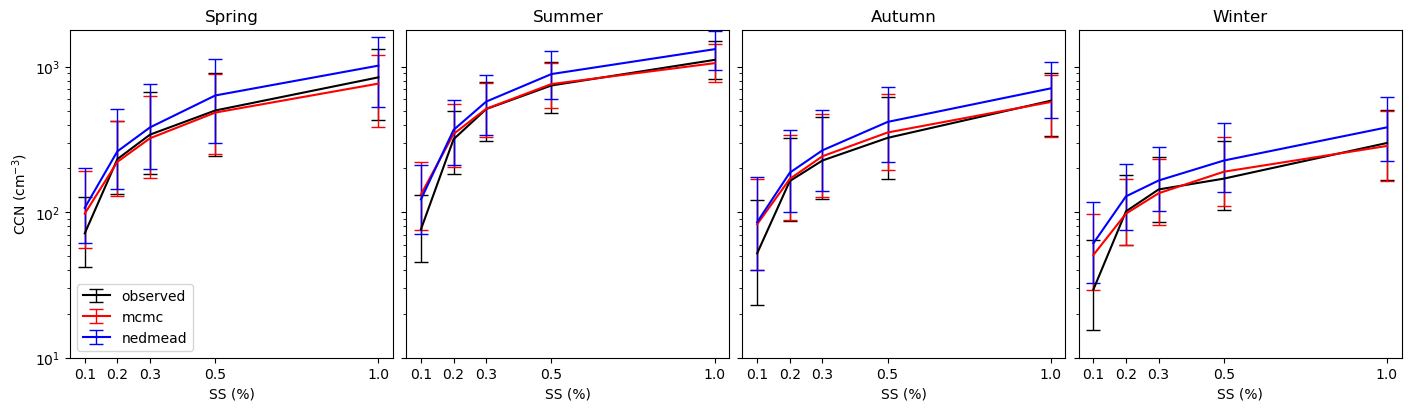

In [ ]:
plot_ccn_spectra(seasonal_stats_all, 'CCN (cm$^{-3}$)')

Text(0, 0.5, 'Counts')

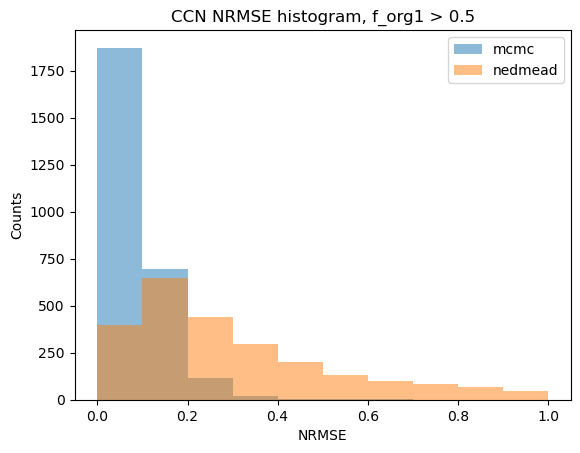

In [23]:
# histogram of different NRMSEs:
bins = np.linspace(0, 1, 11) 
plt.hist(mcmc_results_filtered['NRMSE'].where((mcmc_results_filtered['f_org1'] > 0.5)), bins=bins, alpha=0.5, label='mcmc')
plt.hist(nedmead_results['NRMSE'].where((mcmc_results_filtered['f_org1'] > 0.5)), bins=bins, alpha=0.5, label='nedmead')
plt.legend()
plt.title('CCN NRMSE histogram, f_org1 > 0.5')
plt.xlabel('NRMSE')
plt.ylabel('Counts')

In [70]:
# look at seasonal KDEs of different parameters, split between Aitken and Accumulation modes:
# filter_f_org1 = True for Aitken enriched, False for Aitken depleted (MCMC finds bimodal f_org1)

def seasonal_kde(Aitken_var, Accum_var, xaxis_label, x_lim, solid_line, log_scale=False, filter_f_org1=True):

    fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)

    for season in range(4):
        ax = axes[season]

        if filter_f_org1:
            group_mcmc = mcmc_results_filtered.where((mcmc_results_filtered['season'] == season) & (mcmc_results_filtered['f_org1'] > 0.5))
            group_nedmead = nedmead_results.where((nedmead_results['season'] == season) & (mcmc_results_filtered['f_org1'] > 0.5))
            ylabel = 'KDE Density, Aitken enriched'
        else:
            group_mcmc = mcmc_results_filtered.where((mcmc_results_filtered['season'] == season) & (mcmc_results_filtered['f_org1'] < 0.5))
            group_nedmead = nedmead_results.where((nedmead_results['season'] == season) & (mcmc_results_filtered['f_org1'] < 0.5))
            ylabel = 'KDE Density, Aitken depleted'
    
        sns.kdeplot(group_mcmc[Aitken_var].dropna(), ax=ax, label='mcmc Aitken', color='c', linewidth=1.5, linestyle='--', log_scale=log_scale, cut=0)
        sns.kdeplot(group_mcmc[Accum_var].dropna(), ax=ax, label='mcmc Accumulation', color='pink', linewidth=1.5, linestyle='--', log_scale=log_scale, cut=0)
        sns.kdeplot(group_nedmead[Aitken_var].dropna(), ax=ax, label='nedmead Aitken', color='c', linewidth=1.5, log_scale=log_scale, cut=0)
        sns.kdeplot(group_nedmead[Accum_var].dropna(), ax=ax, label='nedmead Accumulation', color='pink', linewidth=1.5, log_scale=log_scale, cut=0)

        ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
        ax.set_xlim(x_lim)
        ax.set_xlabel(xaxis_label)


    axes[0].set_ylabel(ylabel)

    # Define handles
    aitken_line = mlines.Line2D([], [], color='c', linestyle='-', label='Aitken')
    accum_line = mlines.Line2D([], [], color='pink', linestyle='-', label='Accumulation')

    mcmc_line = mlines.Line2D([], [], color='gray', linestyle='--', label='MCMC posterior median', alpha=0.6)
    iqr_75 = mlines.Line2D([], [], color='gray', linestyle=':', label='MCMC posterior 75%', alpha=0.6)
    iqr_25 = mlines.Line2D([], [], color='gray', linestyle='-.', label='MCMC posterior 25%', alpha=0.6)
    init_line = mlines.Line2D([], [], color='gray', linestyle='-', label=solid_line, alpha=0.6)

    # Add to legend
    axes[0].legend(handles=[aitken_line, accum_line, mcmc_line, init_line])

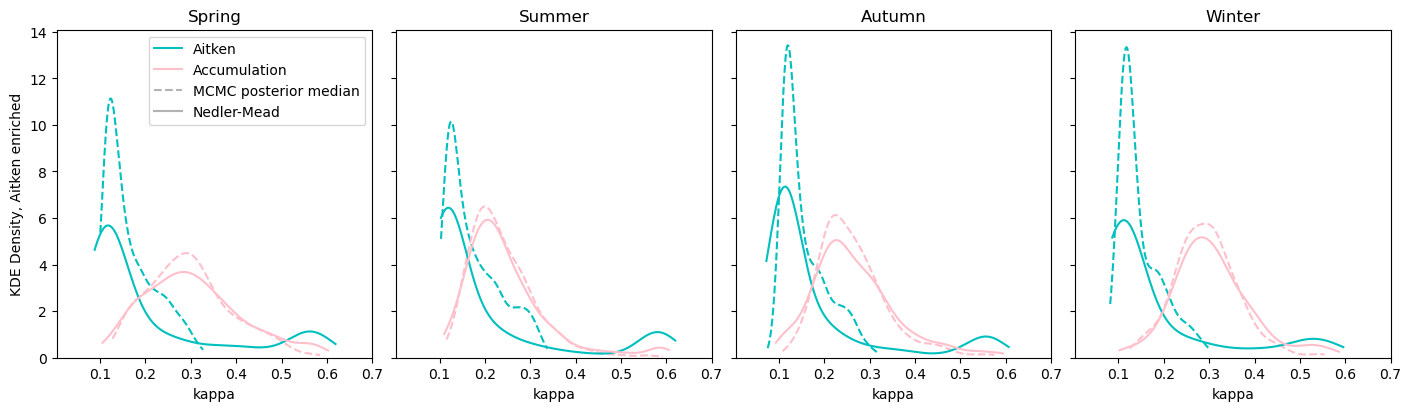

In [ ]:
seasonal_kde('k1','k2','kappa', (0.005, 0.7),'Nedler-Mead', filter_f_org1=True)

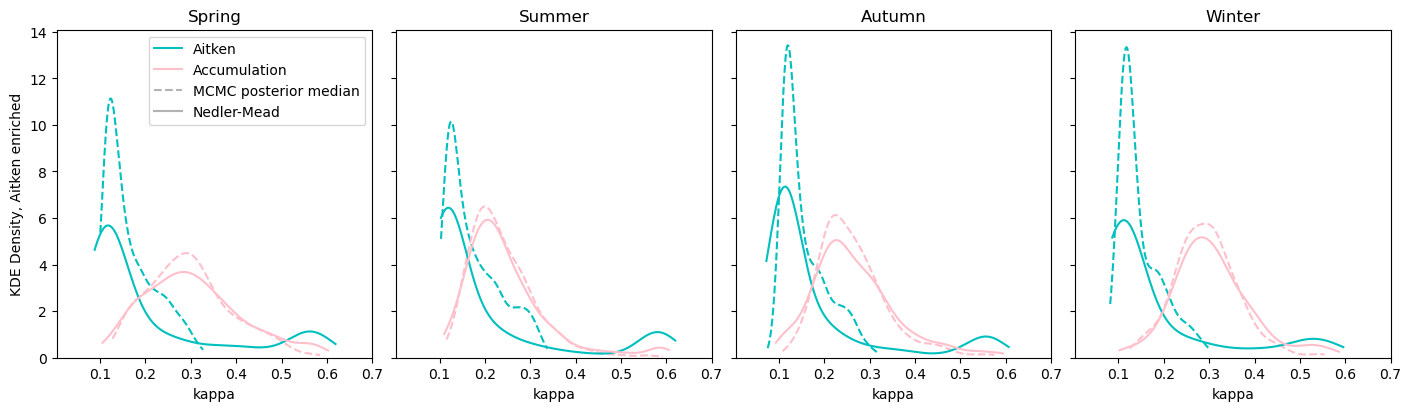

In [25]:
seasonal_kde('k1','k2','kappa', (0.005, 0.7),'Nedler-Mead', filter_f_org1=True)

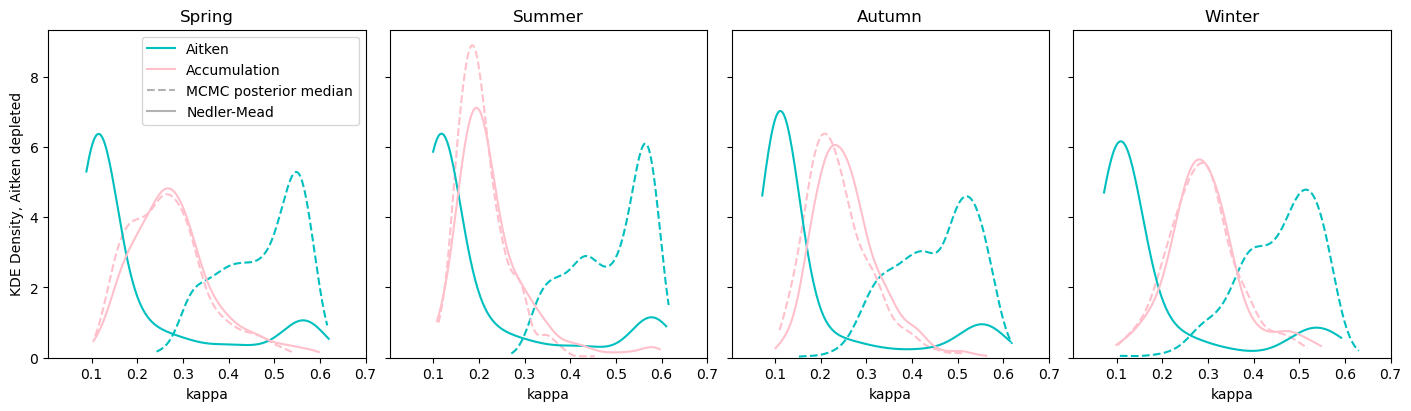

In [27]:
seasonal_kde('k1','k2','kappa', (0.005, 0.7),'Nedler-Mead', filter_f_org1=False)

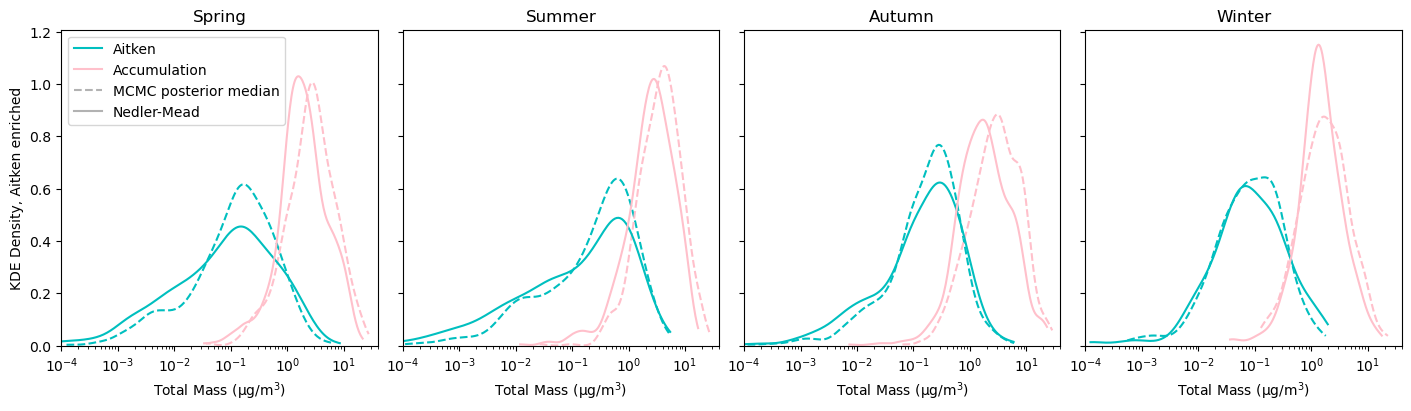

In [26]:
seasonal_kde('mass_aitken', 'mass_accumulation', 'Total Mass (μg/m$^3$)', (0.0001, 40), 'Nedler-Mead', log_scale=True, filter_f_org1=True)


Text(0.5, 1.0, 'mean Ned-Mead Mass Fractions by Season')

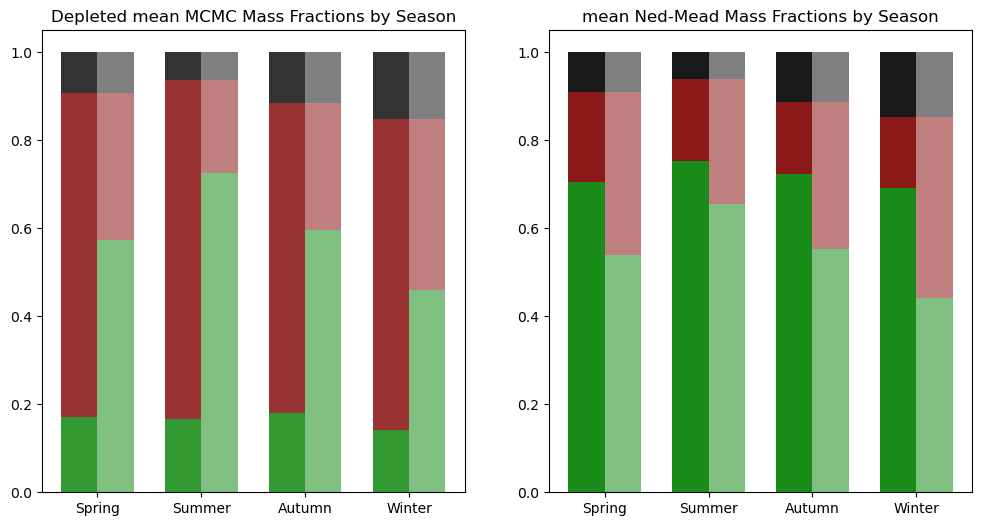

In [28]:
# look at optimized mass fractions by season:

season = [0, 1, 2, 3]
season_labels = ['Spring', 'Summer', 'Autumn', 'Winter']
modes = ['Aitken', 'Accumulation']

seasonal_massfracs = {
    'Aitken' : {
    'f_org': [mcmc_results_filtered['f_org1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    'f_AS': [mcmc_results_filtered['f_AS1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    'f_BC': [mcmc_results_filtered['f_BC1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    },
    'Accumulation' : {
    'f_org': [mcmc_results_filtered['f_org2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    'f_AS': [mcmc_results_filtered['f_AS2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    'f_BC': [mcmc_results_filtered['f_BC2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] < 0.5)).dropna().mean() for i in range(4)],
    }
}

seasonal_massfracs_ned = {
    'Aitken' : {
    'f_org': [nedmead_results['f_org1'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    'f_AS': [nedmead_results['f_AS1'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    'f_BC': [nedmead_results['f_BC1'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    },
    'Accumulation' : {
    'f_org': [nedmead_results['f_org2'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    'f_AS': [nedmead_results['f_AS2'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    'f_BC': [nedmead_results['f_BC2'].where(nedmead_results['season'] == i).dropna().mean() for i in range(4)],
    }
}

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 6)
x = np.arange(len(season_labels))  # the label locations
width = 0.35  # the width of the bars
colors = {'f_org': 'green', 'f_AS': 'maroon', 'f_BC': 'black'}  # Define colors for each label

for i, mode in enumerate(modes):
    bottom = np.zeros(len(season_labels))
    alpha = 0.8 if mode == 'Aitken' else 0.5  # Adjust alpha for visibility
    for label, frac in seasonal_massfracs[mode].items():
        p = ax[0].bar(x + (i-0.5) * width, frac, width=width, label=label, bottom=bottom, color=colors[label], alpha=alpha)
        bottom += frac

for i, mode in enumerate(modes):
    bottom = np.zeros(len(season_labels))
    alpha = 0.9 if mode == 'Aitken' else 0.5  # Adjust alpha for visibility
    for label, frac in seasonal_massfracs_ned[mode].items():
        p = ax[1].bar(x + (i-0.5) * width, frac, width=width, label=label, bottom=bottom, color=colors[label], alpha=alpha)
        bottom += frac

ax[0].set_xticks(x)
ax[0].set_xticklabels(season_labels)
ax[1].set_xticks(x)
ax[1].set_xticklabels(season_labels)

ax[0].set_title('Depleted mean MCMC Mass Fractions by Season')
ax[1].set_title('mean Ned-Mead Mass Fractions by Season')

Text(0.5, 1.0, 'mean Ned-Mead Mass Fractions by Season')

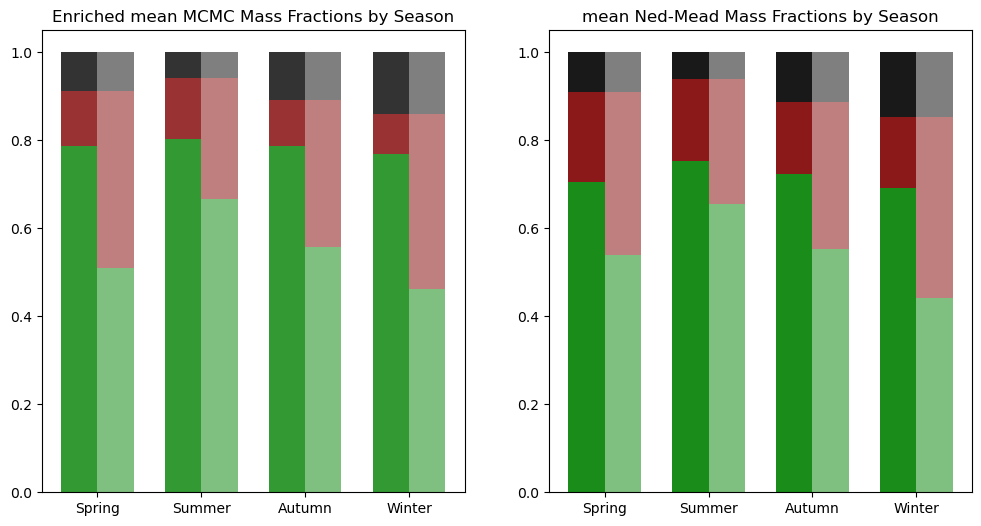

In [29]:
seasonal_massfracs = {
    'Aitken' : {
    'f_org': [mcmc_results_filtered['f_org1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    'f_AS': [mcmc_results_filtered['f_AS1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    'f_BC': [mcmc_results_filtered['f_BC1'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    },
    'Accumulation' : {
    'f_org': [mcmc_results_filtered['f_org2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    'f_AS': [mcmc_results_filtered['f_AS2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    'f_BC': [mcmc_results_filtered['f_BC2'].where((mcmc_results_filtered['season'] == i) & (mcmc_results_filtered['f_org1'] > 0.5)).dropna().mean() for i in range(4)],
    }
}


fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 6)
x = np.arange(len(season_labels))  # the label locations
width = 0.35  # the width of the bars
colors = {'f_org': 'green', 'f_AS': 'maroon', 'f_BC': 'black'}  # Define colors for each label

for i, mode in enumerate(modes):
    bottom = np.zeros(len(season_labels))
    alpha = 0.8 if mode == 'Aitken' else 0.5  # Adjust alpha for visibility
    for label, frac in seasonal_massfracs[mode].items():
        p = ax[0].bar(x + (i-0.5) * width, frac, width=width, label=label, bottom=bottom, color=colors[label], alpha=alpha)
        bottom += frac

for i, mode in enumerate(modes):
    bottom = np.zeros(len(season_labels))
    alpha = 0.9 if mode == 'Aitken' else 0.5  # Adjust alpha for visibility
    for label, frac in seasonal_massfracs_ned[mode].items():
        p = ax[1].bar(x + (i-0.5) * width, frac, width=width, label=label, bottom=bottom, color=colors[label], alpha=alpha)
        bottom += frac

ax[0].set_xticks(x)
ax[0].set_xticklabels(season_labels)
ax[1].set_xticks(x)
ax[1].set_xticklabels(season_labels)

ax[0].set_title('Enriched mean MCMC Mass Fractions by Season')
ax[1].set_title('mean Ned-Mead Mass Fractions by Season')

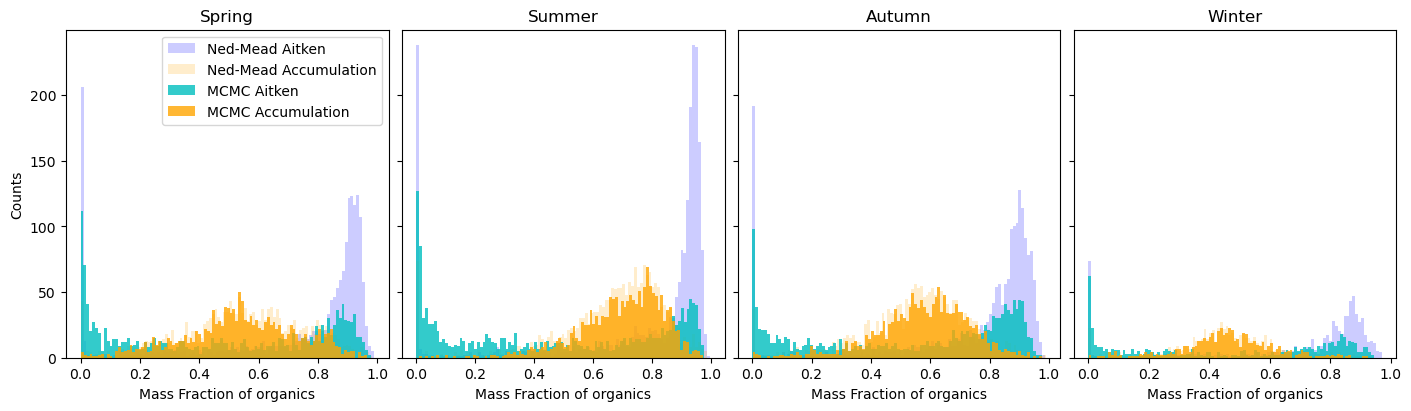

In [30]:
# histogram of optimized mass fractions by season 

fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)

for season in range(4):
    ax = axes[season]

    ax.hist(nedmead_results['f_org1'].where(nedmead_results['season'] == season), color='b', alpha=0.2, label='Ned-Mead Aitken', bins=100)
    ax.hist(nedmead_results['f_org2'].where(nedmead_results['season'] == season), color='orange', alpha=0.2, label='Ned-Mead Accumulation', bins=100)
    ax.hist(mcmc_results_filtered['f_org1'].where((mcmc_results_filtered['season'] == season)), color='c', alpha=0.8, label='MCMC Aitken', bins=100)
    ax.hist(mcmc_results_filtered['f_org2'].where((mcmc_results_filtered['season'] == season)), color='orange', alpha=0.8, label='MCMC Accumulation', bins=100)
    #ax.axvline(mcmc_results_filtered['f_org1'].where(mcmc_results_filtered['season'] == season).mean(), color='c', linestyle='--', label='mean')
    #ax.axvline(mcmc_results_filtered['f_org2'].where(mcmc_results_filtered['season'] == season).mean(), color='orange', linestyle='--', label='')
    #ax.axvline(mcmc_results_filtered['f_org1'].where(mcmc_results_filtered['season'] == season).median(), color='c', label='median')
    #ax.axvline(mcmc_results_filtered['f_org2'].where(mcmc_results_filtered['season'] == season).median(), color='orange', label='')

    ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
    ax.set_xlabel('Mass Fraction of organics')

axes[0].set_ylabel('Counts')
axes[0].legend()


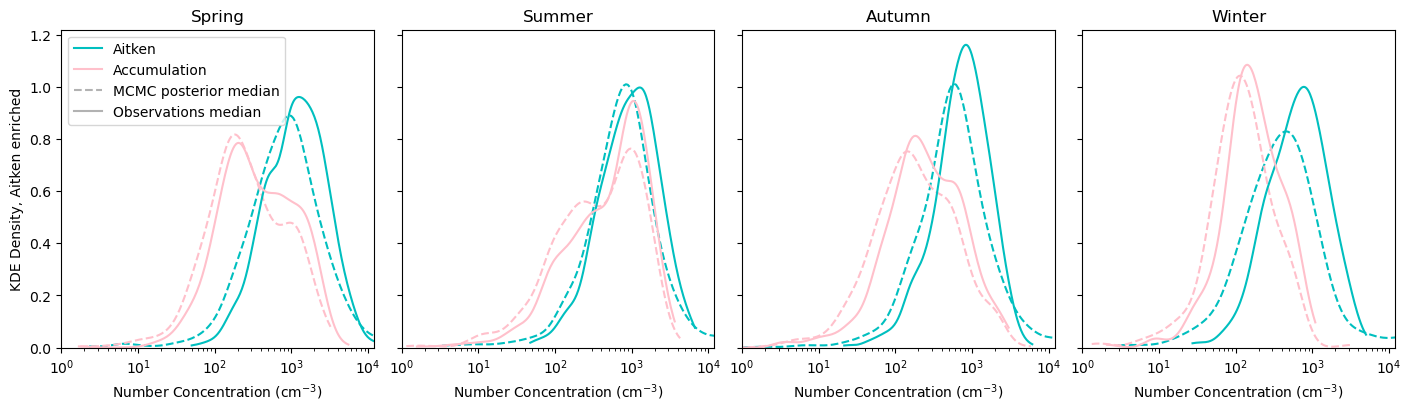

In [31]:
# Seasonal KDE of MCMC parameters vs initial guess, split between Aitken and Accumulation modes:
# filter_f_org1 = True for Aitken enriched, False for Aitken depleted

def seasonal_kde_params(Aitken_var, Accum_var, initial_var1, initial_var2, xaxis_label, x_lim, log_scale=False, filter_f_org1=True):

    fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)

    for season in range(4):
        ax = axes[season]

        if filter_f_org1:
            group_mcmc_params = mcmc_params_filtered.where((mcmc_results_filtered['season'] == season) & (mcmc_results_filtered['f_org1'] > 0.5))
            group_initial_params = bimodal_params.where((bimodal_params['season'] == season) & (mcmc_results_filtered['f_org1'] > 0.5))
            ylabel = 'KDE Density, Aitken enriched'
        else:
            group_mcmc_params = mcmc_params_filtered.where((mcmc_results_filtered['season'] == season) & (mcmc_results_filtered['f_org1'] < 0.5))
            group_initial_params = bimodal_params.where((bimodal_params['season'] == season) & (mcmc_results_filtered['f_org1'] < 0.5))
            ylabel = 'KDE Density, Aitken depleted'

        sns.kdeplot(group_mcmc_params[Aitken_var+'_median'].dropna(), ax=ax, label='mcmc posterior median Aitken', color='c', linewidth=1.5, linestyle='--', log_scale=log_scale, cut=0)
        sns.kdeplot(group_mcmc_params[Accum_var+'_median'].dropna(), ax=ax, label='mcmc posterior median Accum.', color='pink', linewidth=1.5, linestyle='--', log_scale=log_scale, cut=0)
        #sns.kdeplot(group_mcmc_params[Aitken_var+'_75'].dropna(), ax=ax, label='MCMC posterior 75%', color='c', linewidth=1.5, linestyle=':', log_scale=True, cut=0)
        #sns.kdeplot(group_mcmc_params[Aitken_var+'_25'].dropna(), ax=ax, label='MCMC posterior 25%', color='c', linewidth=1.5, linestyle='-.', log_scale=True, cut=0)
        #sns.kdeplot(group_mcmc_params[Accum_var+'_75'].dropna(), ax=ax, label='MCMC posterior 75%', color='pink', linewidth=1.5, linestyle=':', log_scale=True, cut=0)
        #sns.kdeplot(group_mcmc_params[Accum_var+'_25'].dropna(), ax=ax, label='MCMC posterior 25%', color='pink', linewidth=1.5, linestyle='-.', log_scale=True, cut=0)
        sns.kdeplot(group_initial_params[initial_var1].dropna(), ax=ax, label='initial guess Aitken', color='c', linewidth=1.5, log_scale=log_scale, cut=0)
        sns.kdeplot(group_initial_params[initial_var2].dropna(), ax=ax, label='initial guess Accum.', color='pink', linewidth=1.5, log_scale=log_scale, cut=0)

        ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
        ax.set_xlim(x_lim)
        ax.set_xlabel(xaxis_label)

    axes[0].set_ylabel(ylabel)
    # Define handles
    aitken_line = mlines.Line2D([], [], color='c', linestyle='-', label='Aitken')
    accum_line = mlines.Line2D([], [], color='pink', linestyle='-', label='Accumulation')

    mcmc_line = mlines.Line2D([], [], color='gray', linestyle='--', label='MCMC posterior median', alpha=0.6)
    iqr_75 = mlines.Line2D([], [], color='gray', linestyle=':', label='MCMC posterior 75%', alpha=0.6)
    iqr_25 = mlines.Line2D([], [], color='gray', linestyle='-.', label='MCMC posterior 25%', alpha=0.6)
    init_line = mlines.Line2D([], [], color='gray', linestyle='-', label='Observations median', alpha=0.6)

    # Add to legend
    axes[0].legend(handles=[aitken_line, accum_line, mcmc_line, init_line])

seasonal_kde_params('N1','N2', 'NSD1_sum','NSD2_sum','Number Concentration (cm$^{-3}$)', (1.0, 12000), log_scale=True, filter_f_org1=True)



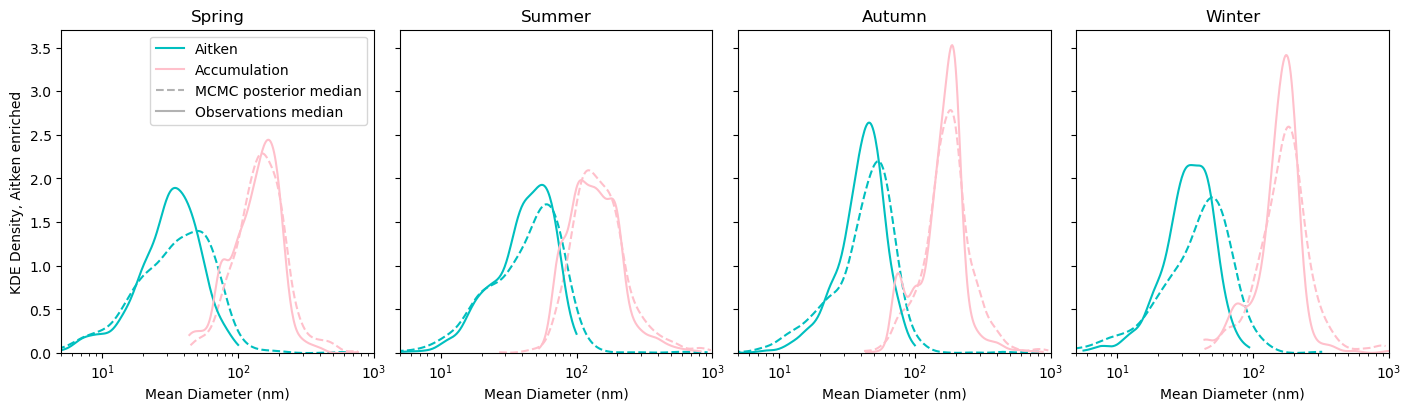

In [32]:
seasonal_kde_params('D1','D2', 'mode1_d','mode2_d','Mean Diameter (nm)', (5.0, 1000), log_scale=True, filter_f_org1=True)

Text(0, 0.5, 'KDE Density')

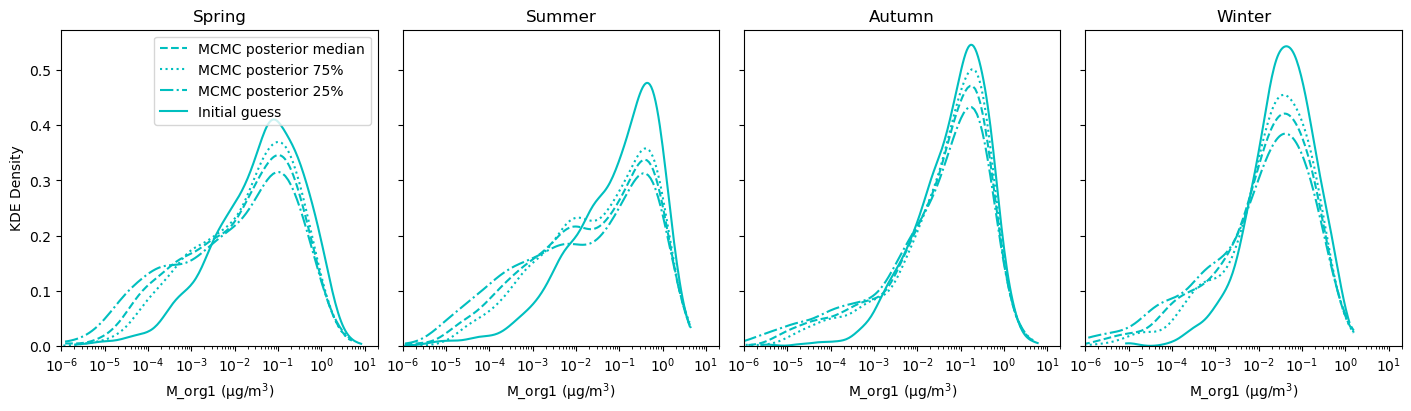

In [33]:
# Look at M_org1 posterior distribution vs initial guess:

m_org1_guess = pd.read_csv('../input_data/M_org1_initialguess.csv')

fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)

for season in range(4):
    ax = axes[season]

    group_mcmc_params = mcmc_params_filtered[mcmc_results_filtered['season'] == season]
    m_org1_initial = m_org1_guess[mcmc_results_filtered['season'] == season]
    nedmead_group = nedmead_results[nedmead_results['season'] == season]
    sns.kdeplot(group_mcmc_params['M_org1_median'].dropna(), ax=ax, label='MCMC posterior median', color='c', linewidth=1.5, linestyle='--', log_scale=True, cut=0)
    sns.kdeplot(group_mcmc_params['M_org1_75'].dropna(), ax=ax, label='MCMC posterior 75%', color='c', linewidth=1.5, linestyle=':', log_scale=True, cut=0)
    sns.kdeplot(group_mcmc_params['M_org1_25'].dropna(), ax=ax, label='MCMC posterior 25%', color='c', linewidth=1.5, linestyle='-.', log_scale=True, cut=0)
    sns.kdeplot(m_org1_initial['M_org1'].dropna(), ax=ax, label='Initial guess', color='c', linewidth=1.5, log_scale=True, cut=0)
    

    ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
    ax.set_xlabel('M_org1 (µg/m$^3$)')
    ax.set_xlim(0.000001, 20)

axes[0].legend()
axes[0].set_ylabel('KDE Density')

/tmp/ipykernel_1375603/4035248818.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
/tmp/ipykernel_1375603/4035248818.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])


[Text(0, 0, 'Spring'),
 Text(1, 0, 'Summer'),
 Text(2, 0, 'Autumn'),
 Text(3, 0, 'Winter')]

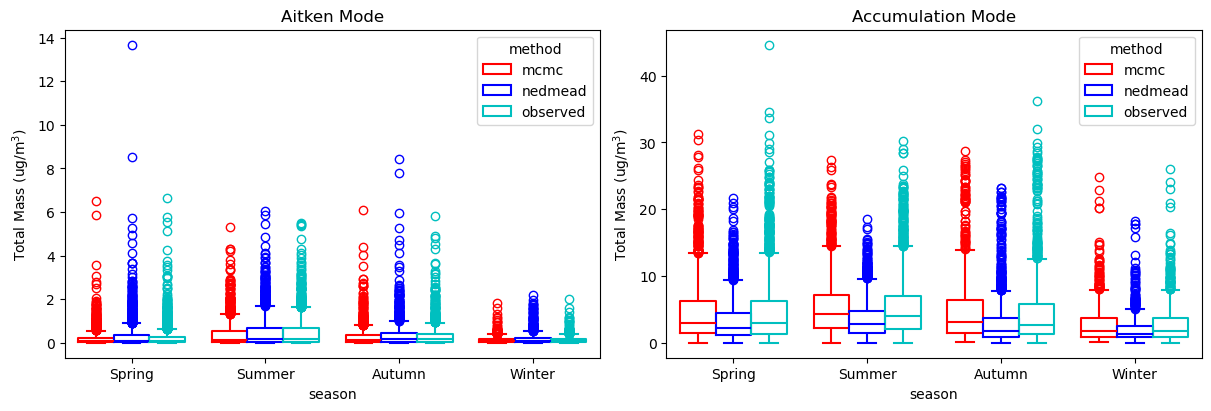

In [34]:
# boxplot of total mass in each mode for each season:

calc_mass = pd.read_csv('/proj/bolinc/users/x_maude/CCN_closure/Modal-Aerosol-Composition/input_data/total_mass_median_NSDparams.csv')

mass_df = pd.DataFrame({
    'datetime': mcmc_results_filtered['datetime'],
    'mass_aitken': mcmc_results_filtered['mass_aitken'],
    'mass_accumulation': mcmc_results_filtered['mass_accumulation'],
    'season': mcmc_results_filtered['season'],
    'method': 'mcmc'
})
mass_df_nedmead = pd.DataFrame({
    'datetime': nedmead_results['datetime'],
    'mass_aitken': nedmead_results['mass_aitken'],
    'mass_accumulation': nedmead_results['mass_accumulation'],
    'season': nedmead_results['season'],
    'method': 'nedmead'
})
mass_df_obs = pd.DataFrame({
    'datetime': calc_mass['datetime'],
    'mass_aitken': calc_mass['aitken_mass'],
    'mass_accumulation': calc_mass['accum_mass'],
    'season': mcmc_results_filtered['season'],
    'method': 'observed'
})
mass_df = pd.concat([mass_df, mass_df_nedmead, mass_df_obs], ignore_index=True)

fig,axes = plt.subplots(ncols=2, nrows=1, figsize=(12,4), constrained_layout=True)

sns.boxplot(x='season', y='mass_aitken', hue='method', data=mass_df, palette=['r','b','c'], fill=False, ax=axes[0])
sns.boxplot(x='season', y='mass_accumulation', hue='method', data=mass_df, palette=['r','b','c'], fill=False, ax=axes[1])
axes[0].set_title('Aitken Mode')
axes[1].set_title('Accumulation Mode')
axes[0].set_ylabel('Total Mass (ug/m$^3$)')
axes[1].set_ylabel('Total Mass (ug/m$^3$)')
axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])

Text(0, 0.5, 'Median MCMC M_org1 (µg/m$^3$)')

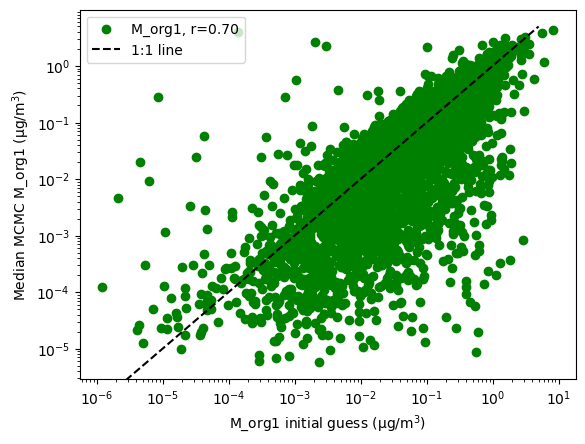

In [35]:
# scatter plot of M_org1 posterior median vs initial guess
rhat_filter_idx = mcmc_params.loc[mcmc_params[rhat_cols].lt(1.5).all(axis=1)].dropna().index

rM1,p1 = stats.pearsonr(m_org1_guess['M_org1'].loc[rhat_filter_idx], mcmc_params_filtered['M_org1_median'].loc[rhat_filter_idx])
plt.scatter(m_org1_guess['M_org1'].loc[rhat_filter_idx], mcmc_params_filtered['M_org1_median'].loc[rhat_filter_idx], label='M_org1, r={:.2f}'.format(rM1), color='g')
plt.plot([0, 5], [0, 5], color='k', linestyle='--', label='1:1 line')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('M_org1 initial guess (µg/m$^3$)')
plt.ylabel('Median MCMC M_org1 (µg/m$^3$)')
#plt.title('Fitted vs MCMC M_org1')


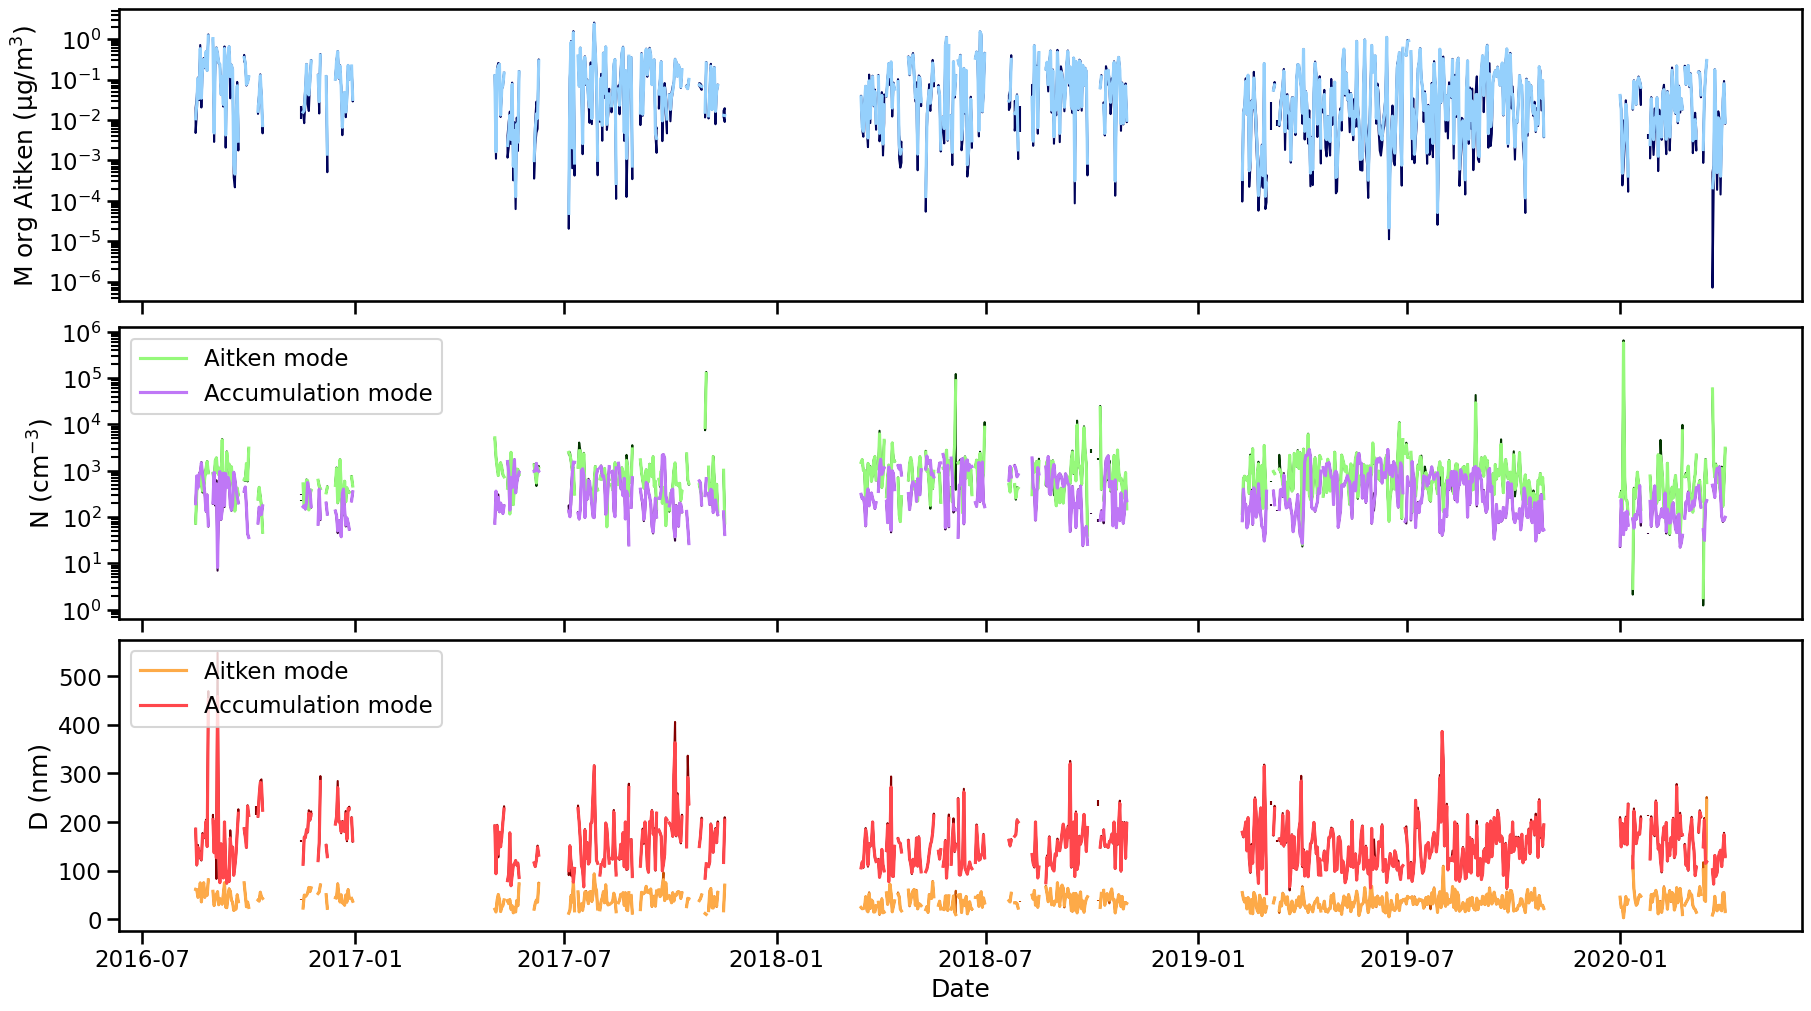

In [ ]:
# time-series of optimized parameters and posterior distribution (25% and 75% intervals):

mcmc_params_filtered['datetime'] = pd.to_datetime(mcmc_params_filtered['datetime'])

mcmc_params_daily = mcmc_params_filtered.groupby(pd.Grouper(key='datetime', freq='D')).median()
#mcmc_params_monthly = mcmc_params_filtered.groupby(pd.Grouper(key='datetime', freq='M')).mean()

#mcmc_params_weekly = mcmc_params_timeseries.rolling(window='7D', center=True, min_periods=3).median()
#mcmc_params_weekly.where(mcmc_params_timeseries.isna(), np.nan, inplace=True)  # Keep NaNs where original data had NaNs

with sns.plotting_context("talk"):
    fig,axes = plt.subplots(ncols=1, nrows=3, figsize=(18,10), constrained_layout=True, sharex=True)

    axes[0].plot(mcmc_params_daily['M_org1_median'],color='xkcd:light blue')
    axes[0].fill_between(mcmc_params_daily.index, mcmc_params_daily['M_org1_25'], mcmc_params_daily['M_org1_75'], color='xkcd:dark blue')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('M org Aitken (µg/m$^3$)')

    axes[1].plot(mcmc_params_daily['N1_median'],color='xkcd:light green', label='Aitken mode')
    axes[1].fill_between(mcmc_params_daily.index, mcmc_params_daily['N1_25'], mcmc_params_daily['N1_75'], color='xkcd:dark green')
    axes[1].plot(mcmc_params_daily['N2_median'],color='xkcd:light purple', label='Accumulation mode')
    axes[1].fill_between(mcmc_params_daily.index, mcmc_params_daily['N2_25'], mcmc_params_daily['N2_75'], color='xkcd:dark purple')
    axes[1].set_yscale('log')
    axes[1].set_ylabel('N (cm$^{-3}$)')
    axes[1].legend(loc='upper left')

    axes[2].plot(mcmc_params_daily['D1_median'],color='xkcd:light orange', label='Aitken mode')
    axes[2].fill_between(mcmc_params_daily.index, mcmc_params_daily['D1_25'], mcmc_params_daily['D1_75'], color='xkcd:dark orange')
    axes[2].plot(mcmc_params_daily['D2_median'],color='xkcd:light red', label='Accumulation mode')
    axes[2].fill_between(mcmc_params_daily.index, mcmc_params_daily['D2_25'], mcmc_params_daily['D2_75'], color='xkcd:dark red')
    axes[2].set_ylabel('D (nm)')
    axes[2].set_xlabel('Date')
    axes[2].legend(loc='upper left')

## 1.3 Detailed MCMC analysis of one time-step (trace plots and marginal pdfs):

In [9]:
# window idx for example:
idx = 4200

#set number of discarded iterations:
burn_in = 20000

#get chains for that window:
chains = sorted(glob.glob('../chains/m2_40k_logparams/mcmc_40k_m2*_'+str(idx)+'_*.csv'))
chains

['../chains/m2_40k_logparams/mcmc_40k_m2_logparams_5chains_4200_0.csv',
 '../chains/m2_40k_logparams/mcmc_40k_m2_logparams_5chains_4200_1.csv',
 '../chains/m2_40k_logparams/mcmc_40k_m2_logparams_5chains_4200_2.csv',
 '../chains/m2_40k_logparams/mcmc_40k_m2_logparams_5chains_4200_3.csv',
 '../chains/m2_40k_logparams/mcmc_40k_m2_logparams_5chains_4200_4.csv']

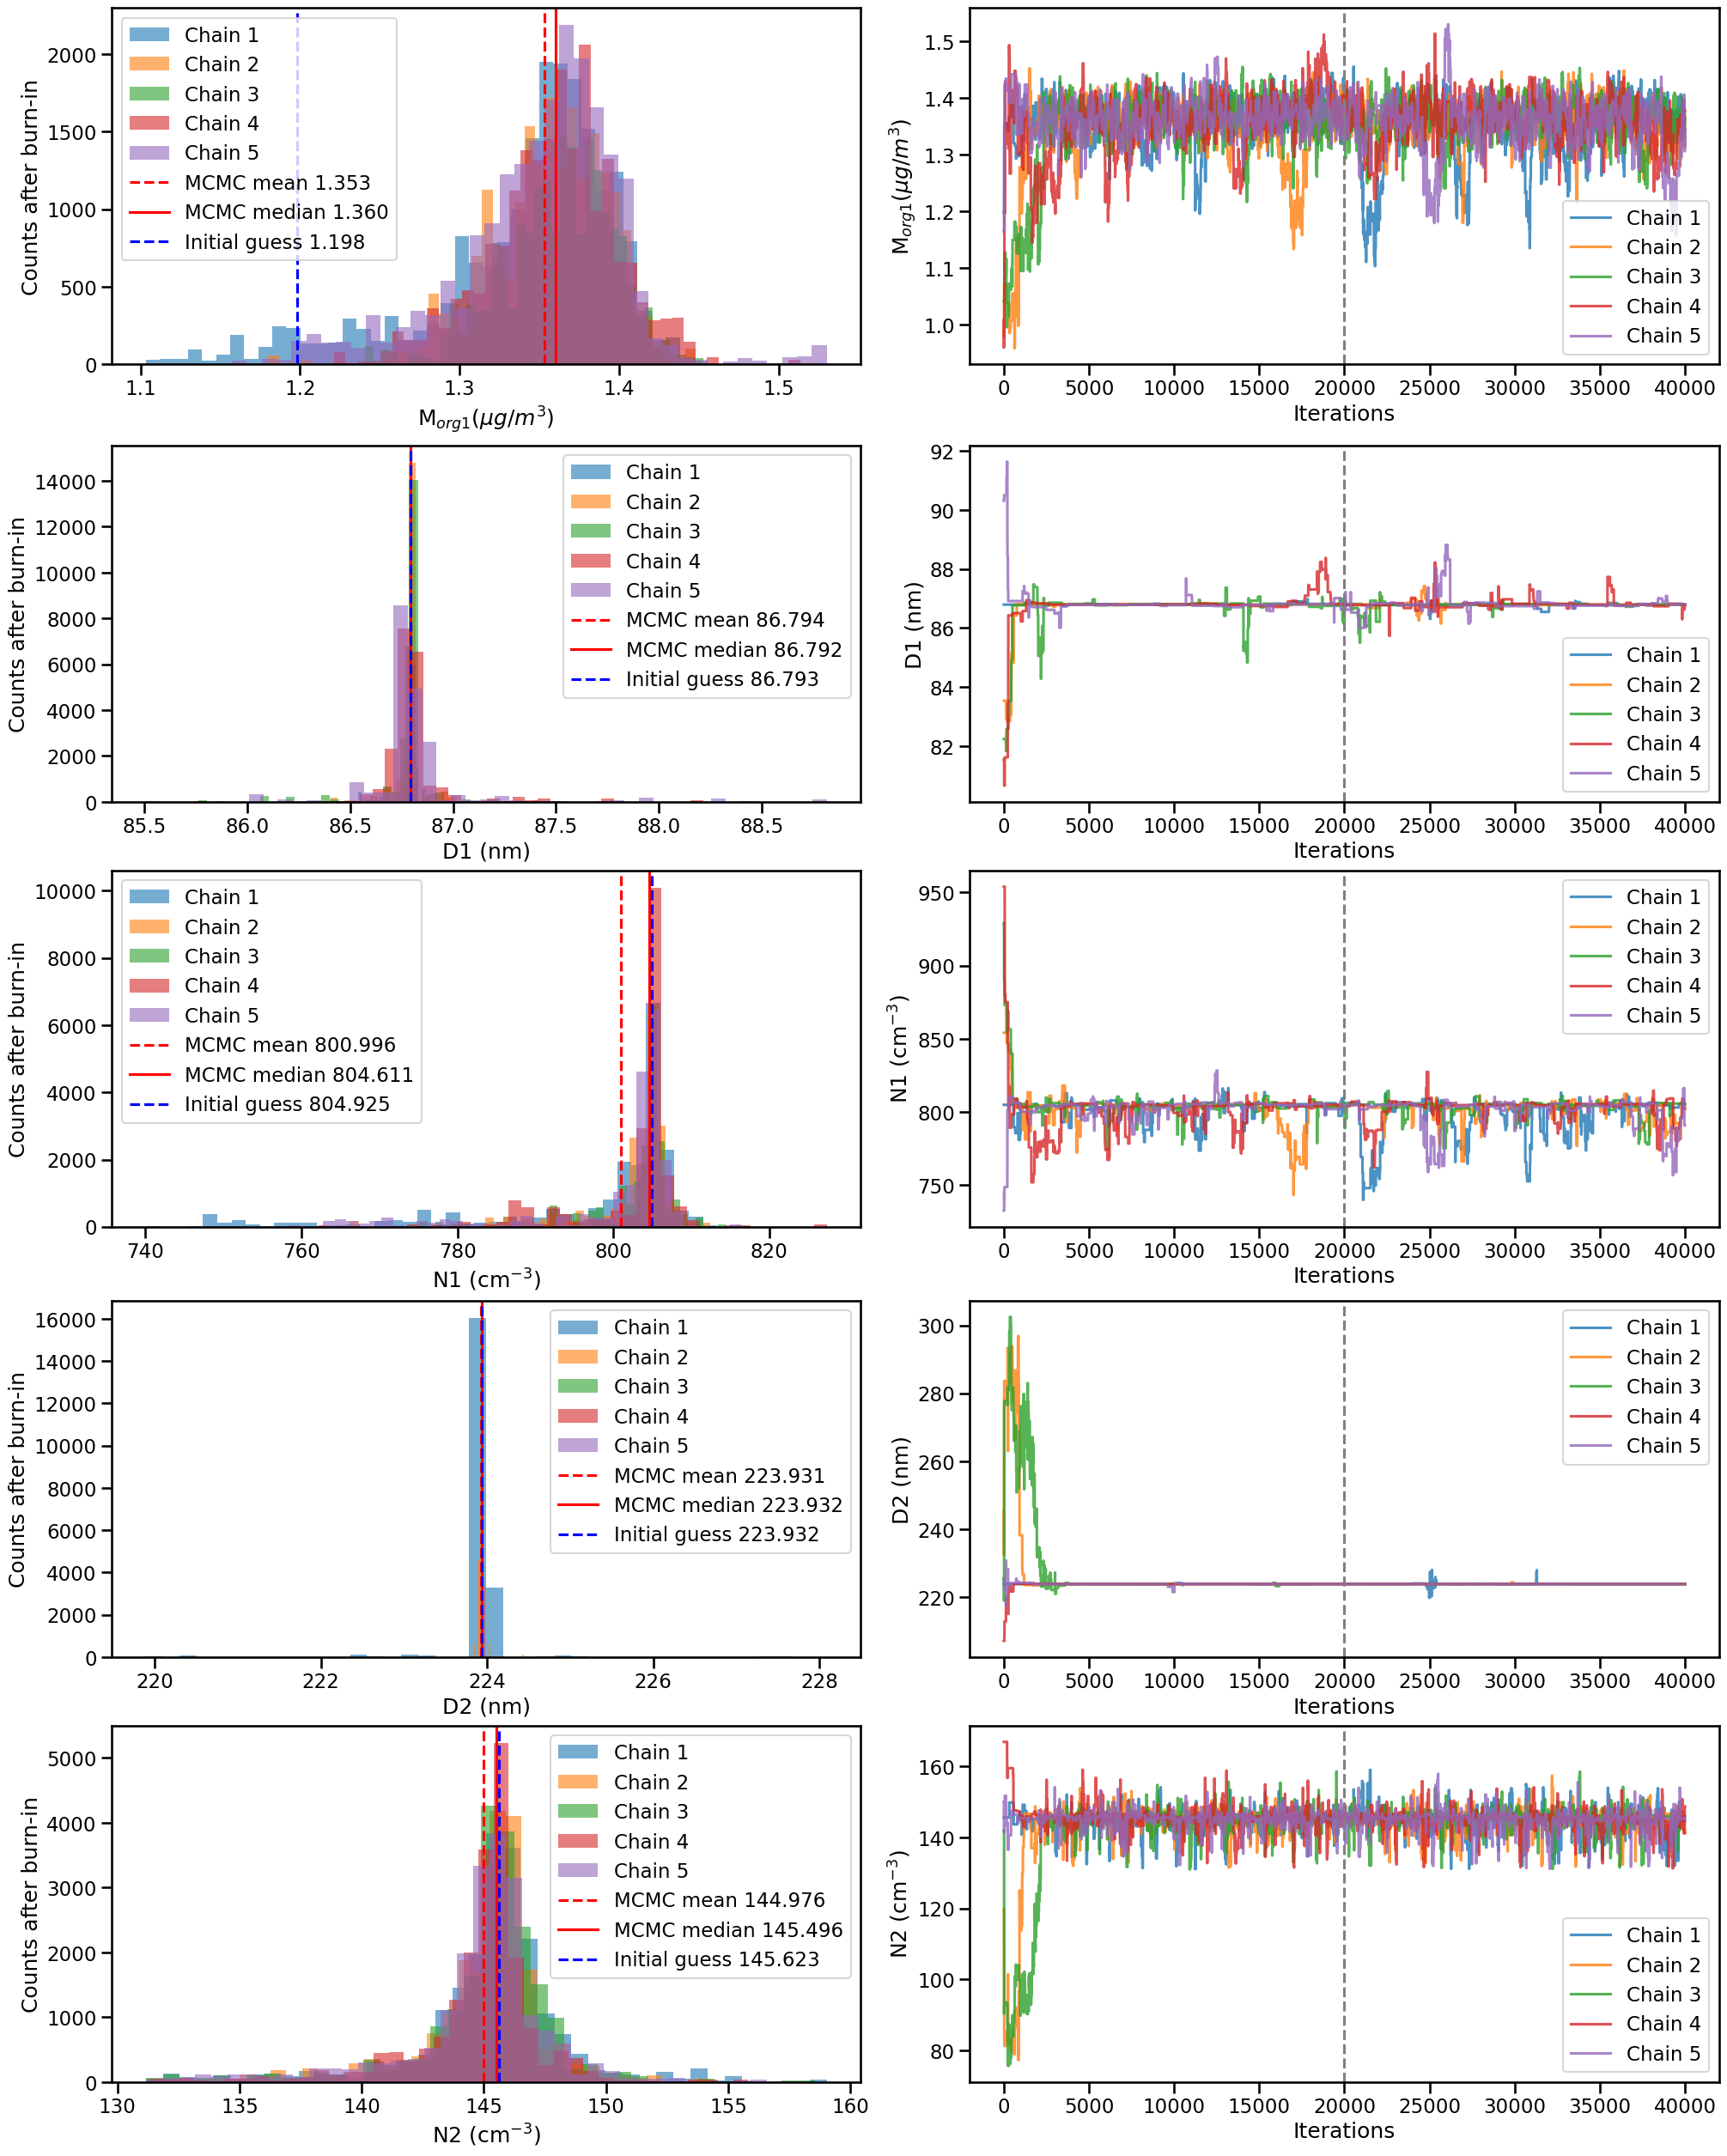

In [10]:
# load data:
M_org1_chains = pints.io.load_samples(chains[0])
D1_chains = pints.io.load_samples(chains[1])
N1_chains = pints.io.load_samples(chains[2])
D2_chains = pints.io.load_samples(chains[3])
N2_chains = pints.io.load_samples(chains[4])

#get initial guesses for parameters:
bimodal_params = pd.read_csv('../input_data/bimodal_params_windows_iqr.csv')
M_org1_initial = pd.read_csv('../input_data/M_org1_initialguess.csv')

plot_multiple_traces(np.stack([M_org1_chains, D1_chains, N1_chains, D2_chains, N2_chains], axis=2), 
                     burn_in, 
                     [M_org1_initial['M_org1'][idx], bimodal_params['mode1_d'][idx], bimodal_params['NSD1_sum'][idx], bimodal_params['mode2_d'][idx], bimodal_params['NSD2_sum'][idx]], 
                     ['M$_{org1} (\mu g/m^3)$', 'D1 (nm)', 'N1 (cm$^{-3}$)', 'D2 (nm)', 'N2 (cm$^{-3}$)'])



In [21]:
# compare CCN spectra:

ss = [0.1,0.2,0.3,0.5,1.0]

ccn_mcmc = mcmc_results_filtered.loc[idx]['Predicted_CCN']
ccn_nedmead = np.fromstring(nedmead_results['Predicted_CCN'][idx].strip('[]'), sep=' ') 
response = observed_results.loc[idx]['CCN']

with sns.plotting_context("talk"):
    fig, axes = plt.subplots(figsize=(8,6))

    axes.loglog(ss, ccn_mcmc, label='MCMC CCN', color='r', marker='o')
    axes.loglog(ss, response, label='observed CCN', color='k', marker='o')
    axes.loglog(ss, ccn_nedmead, label='Ned-Mead CCN', color='b', marker='o')
    axes.legend()
    axes.set_xlabel('SS (%)')
    axes.set_xticks(ss)
    axes.set_xticklabels(ss)
    axes.set_ylabel('CCN (cm$^{-3}$)')



NameError: name 'mcmc_results_filtered' is not defined

(<Figure size 1500x1500 with 25 Axes>,
 array([[<Axes: ylabel='Frequency'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='D1 (nm)'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='N1 (cm$^{-3}$)'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='D2 (nm)'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='M_org1 (μg/m$^3$)', ylabel='N2 (cm$^{-3}$)'>,
         <Axes: xlabel='D1 (nm)'>, <Axes: xlabel='N1 (cm$^{-3}$)'>,
         <Axes: xlabel='D2 (nm)'>, <Axes: xlabel='N2 (cm$^{-3}$)'>]],
       dtype=object))

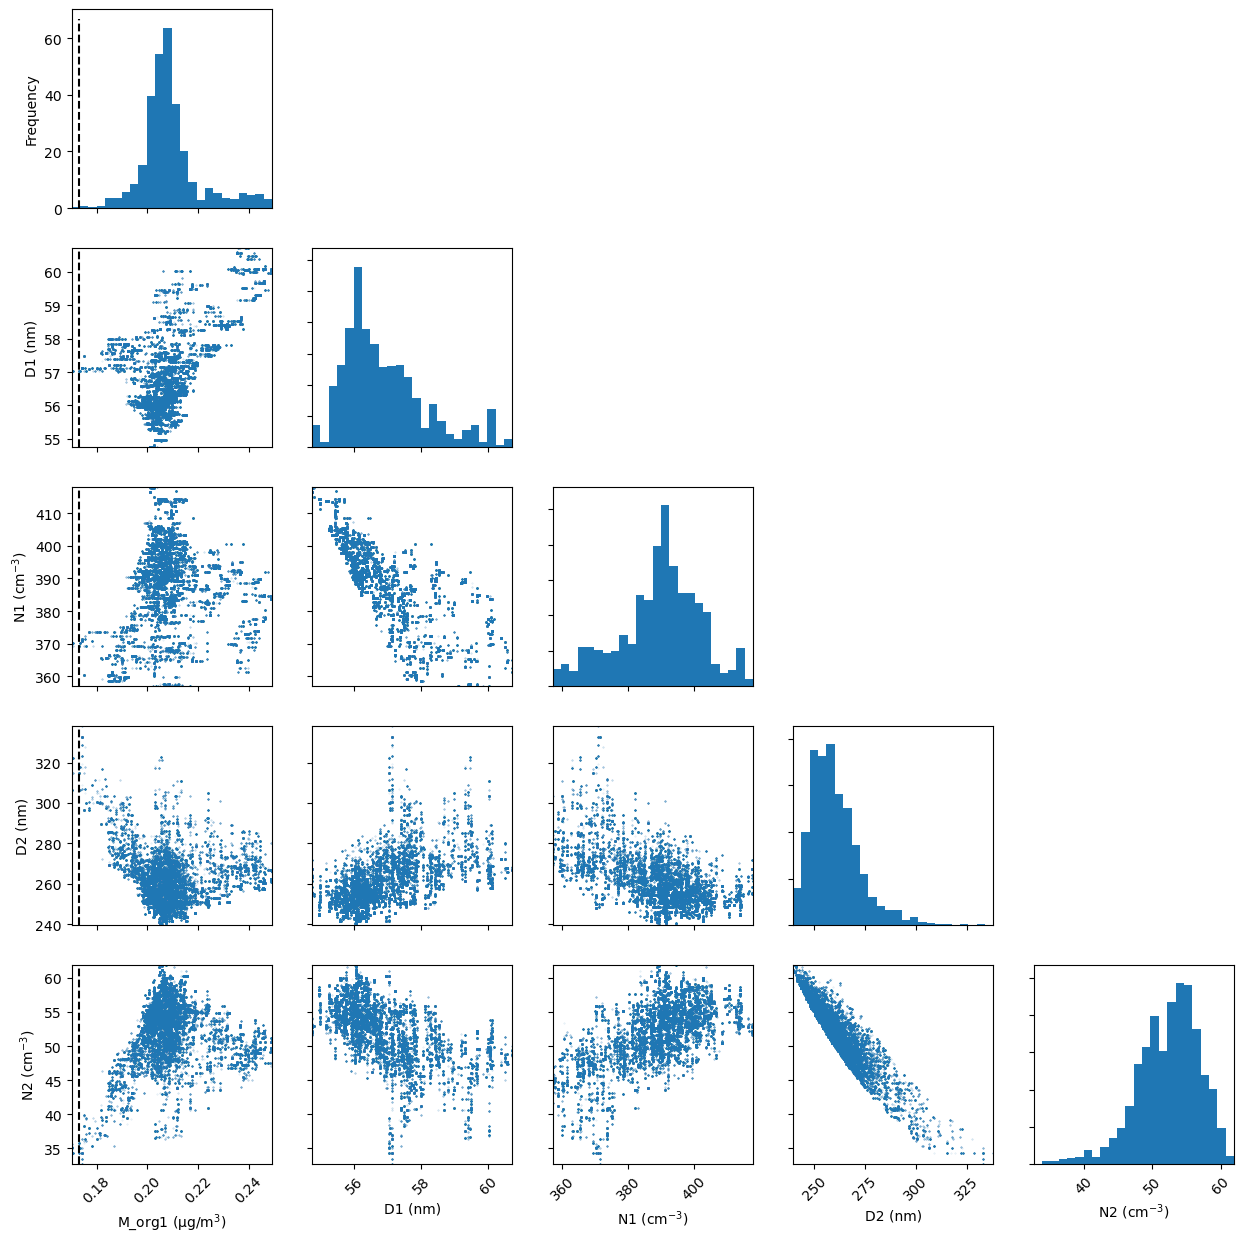

In [17]:
chains_stack = np.stack([M_org1_chains[:,burn_in:], D1_chains[:,burn_in:], N1_chains[:,burn_in:], D2_chains[:,burn_in:], N2_chains[:,burn_in:]], axis=2)
pints.plot.pairwise(np.vstack(chains_stack), kde=False, parameter_names=['M_org1 (μg/m$^3$)', 'D1 (nm)', 'N1 (cm$^{-3}$)', 'D2 (nm)', 'N2 (cm$^{-3}$)'], ref_parameters=[M_org1_initial['M_org1'][idx], bimodal_params['mode1_d'][idx], bimodal_params['NSD1_sum'][idx], bimodal_params['mode2_d'][idx], bimodal_params['NSD2_sum'][idx]])

# 2. Optimizing only organic mode kappa and density

In [7]:
# load mcmc summary statistics:
mcmc_params_org_only = pd.read_csv('../results/summary_m3_orgparams_only.csv')

In [10]:
print('Median kappa across all windows: ', mcmc_params_org_only['kappa_median'].median())
print('Median density across all windows: ', mcmc_params_org_only['density_median'].median())

Median kappa across all windows:  1003.9901555953845
Median density across all windows:  0.0504958296092251


In [14]:
#add season
mcmc_params_org_only['season'] = pd.to_datetime(mcmc_params_org_only['datetime']).apply(get_season)

/tmp/ipykernel_58119/2120849567.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
/tmp/ipykernel_58119/2120849567.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])


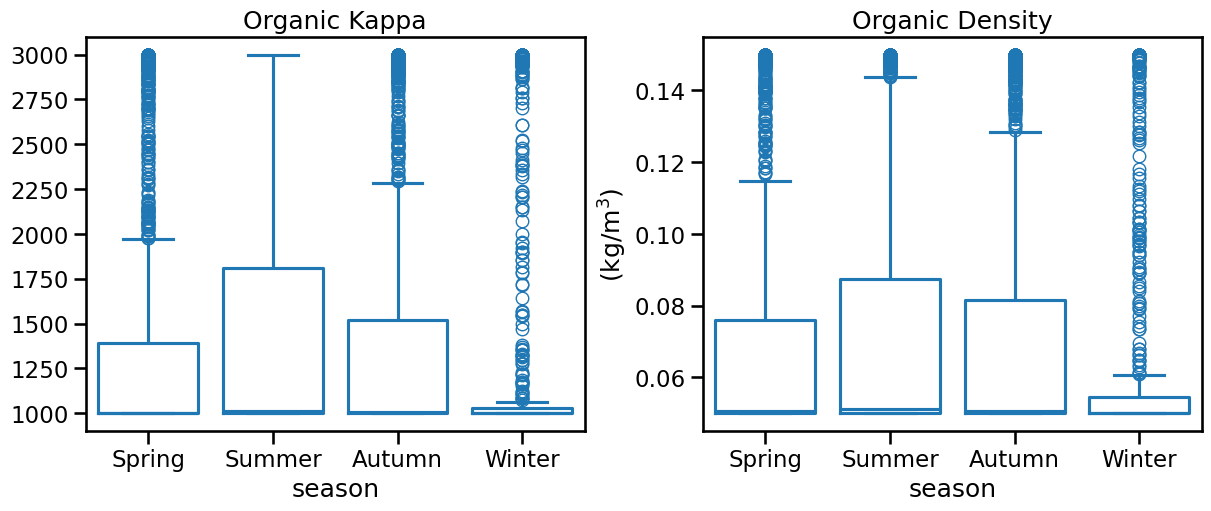

In [20]:
with sns.plotting_context("talk"):
    fig,axes = plt.subplots(ncols=2, nrows=1, figsize=(12,5), constrained_layout=True)

    sns.boxplot(x='season', y='kappa_median', data=mcmc_params_org_only, fill=False, ax=axes[0])
    sns.boxplot(x='season', y='density_median', data=mcmc_params_org_only, fill=False, ax=axes[1])
    axes[0].set_title('Organic Kappa')
    axes[1].set_title('Organic Density')
    axes[0].set_ylabel('')
    axes[1].set_ylabel('(kg/m$^3$)')
    axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
    axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])

# 3. Optimizing organic kappa and density, as well as size distribution parameters:

In [3]:
mcmc_params_org_and_size = pd.read_csv('../results/summary_m4_org_and_sizeparams.csv')

In [8]:
#add season
mcmc_params_org_and_size['season'] = pd.to_datetime(mcmc_params_org_and_size['datetime']).apply(get_season)

In [9]:
print('Median kappa across all windows: ', mcmc_params_org_and_size['Kappa_org_median'].median())
print('Median density across all windows: ', mcmc_params_org_and_size['Rho_org_median'].median())

Median kappa across all windows:  0.0711836778020833
Median density across all windows:  2179.252564254698


/tmp/ipykernel_58119/3399252806.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
/tmp/ipykernel_58119/3399252806.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])


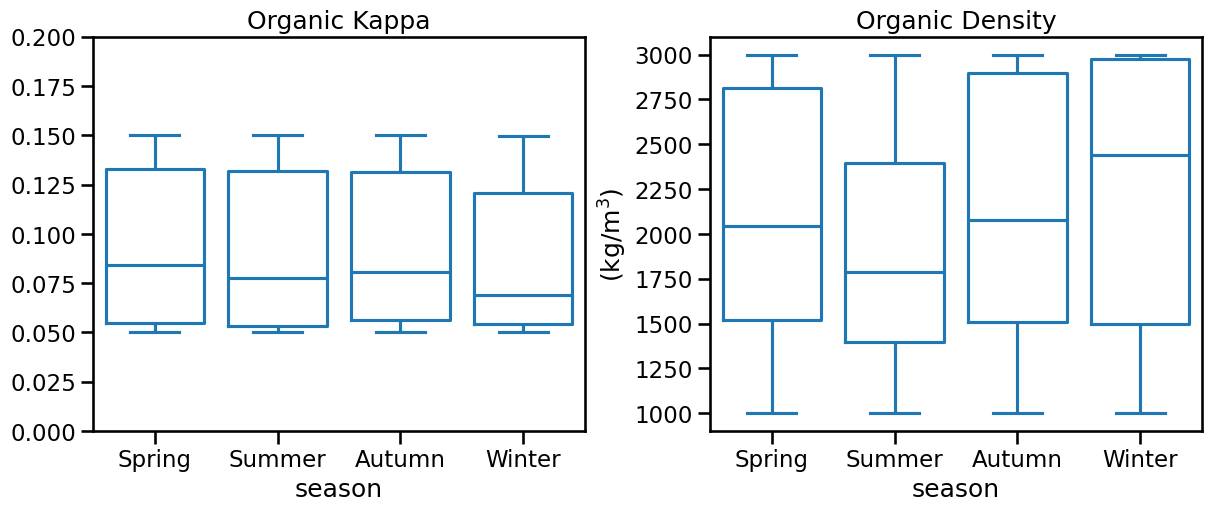

In [33]:
with sns.plotting_context("talk"):
    fig,axes = plt.subplots(ncols=2, nrows=1, figsize=(12,5), constrained_layout=True)

    sns.boxplot(x='season', y='Kappa_org_median', data=mcmc_params_org_and_size.loc[rhat_index_m3], fill=False, ax=axes[0])
    sns.boxplot(x='season', y='Rho_org_median', data=mcmc_params_org_and_size.loc[rhat_index_m3], fill=False, ax=axes[1])
    axes[0].set_ylim(0, 0.2)
    axes[0].set_title('Organic Kappa')
    axes[1].set_title('Organic Density')
    axes[0].set_ylabel('')
    axes[1].set_ylabel('(kg/m$^3$)')
    axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
    axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])

In [31]:
# how many time-steps show convergence (rhat < 1.5):
rhat_thresh = 2.5
rhat_cols = ['Rho_org_rhat', 'Kappa_org_rhat', 'D1_rhat', 'N1_rhat', 'D2_rhat', 'N2_rhat']
num_conv_m3 = mcmc_params_org_and_size.loc[mcmc_params_org_and_size[rhat_cols].lt(rhat_thresh).all(axis=1)].dropna()

print(f"Number of total time-teps showing convergence (rhat < {rhat_thresh}): {num_conv_m3.shape[0]} out of {len(mcmc_params_org_and_size.dropna())}")

Number of total time-teps showing convergence (rhat < 2.5): 3594 out of 6572


In [147]:
# get index of time-steps where mcmc converged for all parameters:
rhat_index_m3 = num_conv_m3.index
# get time-steps where mcmc did not converge:
not_converged = mcmc_params_org_and_size.index.difference(rhat_index_m3)

print(f"Number of time-steps where rhat > {rhat_thresh} for at least one parameter: {len(not_converged)}")

Number of time-steps where rhat > 2.5 for at least one parameter: 2986


In [79]:
# calculate CCN from mcmc results (uncomment last line to save, or load farther down)
from models import CCNmodel_m4

mcmc_results_m3 = pd.DataFrame({'datetime': mcmc_params_org_and_size['datetime']})

cols_to_add = [
    'NRMSE', 'predicted_CCN1', 'predicted_CCN2', 'inorg_density', 'Predicted_CCN',
    'f_org1', 'f_AS1', 'f_BC1', 'f_org2', 'f_AS2', 'f_BC2',
    'k1', 'k2', 'mass_aitken', 'mass_accumulation'
]

for col in cols_to_add:
    if col in ['predicted_CCN1', 'predicted_CCN2', 'Predicted_CCN']:
        mcmc_results_m3[col] = pd.Series([np.nan]*5, dtype='object')
    else:
        mcmc_results_m3[col] = np.nan

check_rows = [] #rows with mcmc output, but medians do not give valid CCN results.ss

all_cols_to_nan = mcmc_results_m3.columns.difference(['datetime'])

for ii in rhat_index_m3:

    # skip rows with NaN:
    if pd.isna(mcmc_params_org_and_size.iloc[ii]).any():
        mcmc_results_m3.loc[ii, all_cols_to_nan] = np.nan

    else:
        try:
            Extra = get_Extra(ii)
            model_data, initial_guesses, prior_params, response = load_data(ii)
            m = CCNmodel_m4(Extra, model_data, return_all=True)

            model_parameters = [mcmc_params_org_and_size.iloc[ii]['Rho_org_median'], mcmc_params_org_and_size.iloc[ii]['Kappa_org_median'], mcmc_params_org_and_size.iloc[ii]['D1_median'], mcmc_params_org_and_size.iloc[ii]['N1_median'], mcmc_params_org_and_size.iloc[ii]['D2_median'], mcmc_params_org_and_size.iloc[ii]['N2_median']]
            ccn1, ccn2, k1, k2, k_inorg1, k_inorg2, mass_frac_aitken, mass_frac_accumulation, total_ait_mass, total_acc_mass, total_mass,info_mass, NSD1_vec, NSD2_vec = m(model_parameters)

            nrmse = np.sqrt(np.mean((response - (ccn1+ccn2))**2)) / np.mean(response)

            mcmc_results_m3.at[ii, 'NRMSE'] = nrmse
            mcmc_results_m3.at[ii, 'predicted_CCN1'] = ccn1
            mcmc_results_m3.at[ii, 'predicted_CCN2'] = ccn2
            mcmc_results_m3.at[ii, 'inorg_density'] = Extra['rho_inorg']
            mcmc_results_m3.at[ii, 'Predicted_CCN'] = ccn1 + ccn2
            mcmc_results_m3.at[ii, 'f_org1'] = mass_frac_aitken[0]
            mcmc_results_m3.at[ii, 'f_AS1'] = mass_frac_aitken[2]
            mcmc_results_m3.at[ii, 'f_BC1'] = mass_frac_aitken[4]
            mcmc_results_m3.at[ii, 'f_org2'] = mass_frac_accumulation[0]
            mcmc_results_m3.at[ii, 'f_AS2'] = mass_frac_accumulation[2]
            mcmc_results_m3.at[ii, 'f_BC2'] = mass_frac_accumulation[4]
            mcmc_results_m3.at[ii, 'k1'] = k1
            mcmc_results_m3.at[ii, 'k2'] = k2
            mcmc_results_m3.at[ii, 'mass_aitken'] = total_ait_mass
            mcmc_results_m3.at[ii, 'mass_accumulation'] = total_acc_mass
            mcmc_results_m3.at[ii, 'tot_org_mass'] = info_mass['tot_org']
            mcmc_results_m3.at[ii, 'info_mass'] = info_mass

        except Exception as e:
            print(f"No model output for median parameters for row {ii}: {e}")
            mcmc_results_m3.loc[ii, all_cols_to_nan] = np.nan
            check_rows.append(ii)
            continue

No model output for median parameters for row 0: Incompatible indexer with Series
No model output for median parameters for row 56: cannot unpack non-iterable NoneType object
No model output for median parameters for row 137: cannot unpack non-iterable NoneType object
No model output for median parameters for row 170: cannot unpack non-iterable NoneType object
No model output for median parameters for row 195: cannot unpack non-iterable NoneType object
No model output for median parameters for row 211: cannot unpack non-iterable NoneType object
No model output for median parameters for row 234: cannot unpack non-iterable NoneType object
No model output for median parameters for row 288: cannot unpack non-iterable NoneType object
No model output for median parameters for row 341: cannot unpack non-iterable NoneType object
No model output for median parameters for row 391: cannot unpack non-iterable NoneType object
No model output for median parameters for row 464: cannot unpack non-iter

In [7]:
mcmc_results_m3 = pd.read_csv('../results/mcmc_results_m3_orgparams_and_size_filtered.csv')

In [8]:
mcmc_results_m3['season'] = pd.to_datetime(mcmc_results_m3['datetime']).apply(get_season)

In [20]:
mcmc_results_m3['Predicted_CCN'].dropna()

1       [116.38042385 196.42590417 235.5709118  276.58...
4       [150.43409184 296.94319645 404.17570538 562.60...
5       [158.61786529 323.43310651 438.10080003 594.95...
6       [128.13936465 339.73083404 492.09347761 674.69...
7       [139.14485073 362.54963051 524.27403679 708.85...
                              ...                        
6573    [ 48.8333755   72.1426438   82.28514995  90.61...
6575    [10.32203163 38.5857305  51.38708308 58.051081...
6576    [ 33.30650026  59.88384607  73.32831301  85.80...
6578    [ 21.93110984  73.4540428   99.16600747 115.78...
6579    [ 50.12313442  92.13168258 108.80580379 129.41...
Name: Predicted_CCN, Length: 3493, dtype: object

In [14]:
seasonal_stats_mcmc

,season,source,median,p25,p75
0,0,mcmc,NaN,NaN,NaN
1,1,mcmc,NaN,NaN,NaN
2,2,mcmc,NaN,NaN,NaN
3,3,mcmc,NaN,NaN,NaN


ValueError: 'x' and 'y' must have the same size

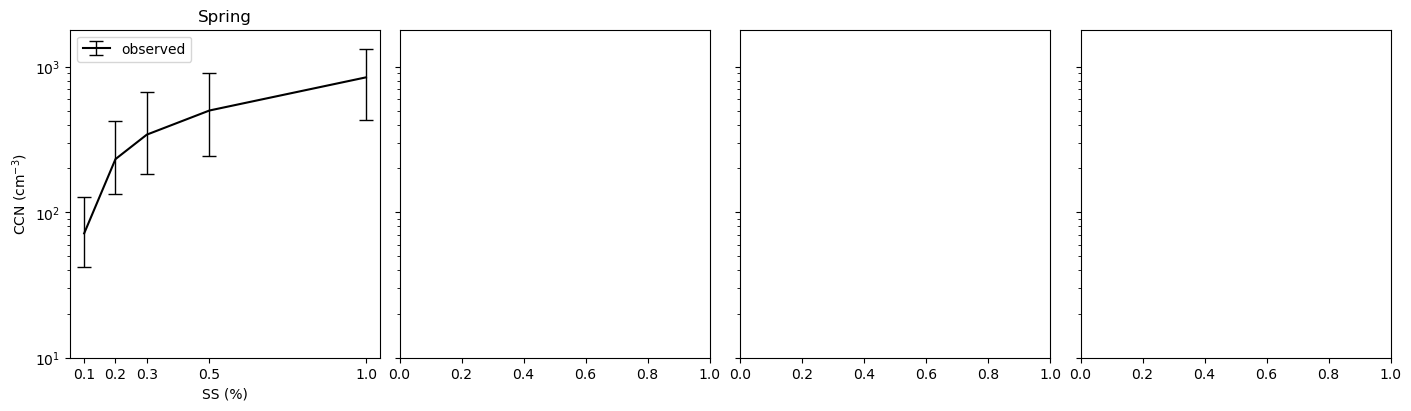

In [12]:
#plot CCN spectra:
nedmead_results['season'] = pd.to_datetime(nedmead_results['datetime']).apply(get_season)
observed_results['season'] = pd.to_datetime(observed_results['datetime']).apply(get_season)

seasonal_stats_mcmc = compute_seasonal_stats(mcmc_results_m3, 'Predicted_CCN', 'mcmc')
#seasonal_stats_nedmead = compute_seasonal_stats(nedmead_results, 'Predicted_CCN', 'nedmead')
seasonal_stats_obs = compute_seasonal_stats(observed_results, 'CCN', 'observed')

# Combine all into one DataFrame
seasonal_stats_all = pd.concat([seasonal_stats_mcmc, seasonal_stats_obs], ignore_index=True)

plot_ccn_spectra(seasonal_stats_all, 'CCN (cm$^{-3}$)')

In [29]:
# get NRMSE for each SS:
merged = pd.concat(
    [mcmc_results_m3["Predicted_CCN"], observed_results["CCN"]],
    axis=1,
    join="inner"
)

# Drop rows where either column is NaN
merged = merged.dropna()

# Now unpack into arrays
arr1 = np.vstack(
    merged["Predicted_CCN"].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=" ")
    )
)
arr2 = np.vstack(merged["CCN"].values)

# Function for NRMSE
def nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))   # RMSE per column
    denom = np.mean(y_true, axis=0)   # range per column
    return rmse / denom

# Compute NRMSE per column (5 values)
nrmse_values = nrmse(arr2,arr1)

# Take median across rows for each of the 5 positions
median_nrmse = np.median(nrmse_values)

print("NRMSE values per position:", np.round(nrmse_values, 4))
print("Median NRMSE:", median_nrmse)

NRMSE values per position: [0.7233 0.2951 0.2291 0.5114 0.5687]
Median NRMSE: 0.5114065620852076


In [24]:
nrmse(arr2[0:2],arr1[0:2])

array([[0.17786039, 0.22914969, 0.10074392, 0.03807537, 0.09290829],
       [0.16269524, 0.13371526, 0.05506914, 0.01765909, 0.04191   ]])

Text(0, 0.5, 'KDE Density')

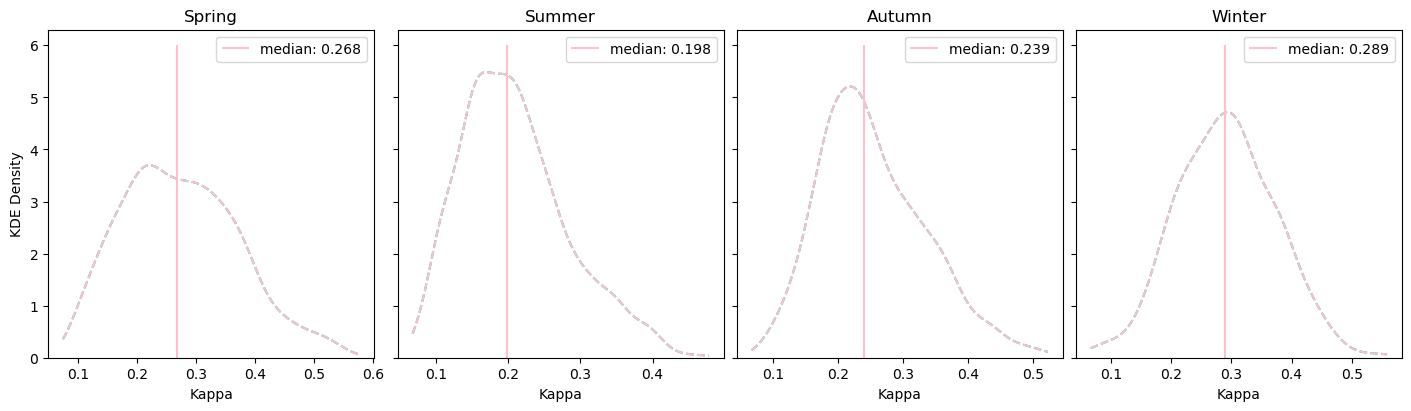

In [20]:
#plot kappa for each mode:
fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)
for season in range(4):
    ax = axes[season]

    group_mcmc = mcmc_results_m3.where((mcmc_results_m3['season'] == season))
    
    sns.kdeplot(group_mcmc['k1'].dropna(), ax=ax, color='c', linewidth=1.5, linestyle='--', cut=0)
    sns.kdeplot(group_mcmc['k2'].dropna(), ax=ax, color='pink', linewidth=1.5, linestyle='--', cut=0)

    median_val = group_mcmc['k1'].median()
    ax.vlines(median_val, 0, 6, color='pink', linestyle='-', label=f"median: {median_val:.3f}")

    ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
    ax.set_xlabel('Kappa')
    ax.legend()

axes[0].set_ylabel('KDE Density')



In [148]:
#save results
mcmc_params_org_and_size.loc[not_converged, all_cols_to_nan] = np.nan
mcmc_params_org_and_size.to_csv('../results/summary_m3_orgparams_and_size_filtered.csv')

mcmc_results_m3.loc[not_converged, all_cols_to_nan] = np.nan
mcmc_results_m3.to_csv('../results/mcmc_results_m3_orgparams_and_size_filtered.csv')

# 4. Optimizing the mass fractions of BC, Org, and size distribution parameters:

In [65]:
mcmc_params_bc_org_size = pd.read_csv('../results/summary_m5_bc_and_sizeparams.csv')

In [66]:
mcmc_params_bc_org_size['season'] = pd.to_datetime(mcmc_params_bc_org_size['datetime']).apply(get_season)

In [69]:
print('Median BC fraction across all windows: ', mcmc_params_bc_org_size['M_BC1_median'].median())
print('Median organic fraction across all windows: ', mcmc_params_bc_org_size['M_org1_median'].median())

Median BC fraction across all windows:  0.0277611623910036
Median organic fraction across all windows:  0.0273611463556639


In [107]:
# how many time-steps show convergence (rhat < 1.5):
rhat_thresh = 2.5
rhat_cols = ['M_BC1_rhat', 'M_org1_rhat', 'D1_rhat', 'N1_rhat', 'D2_rhat', 'N2_rhat']
num_conv_m5 = mcmc_params_bc_org_size.loc[mcmc_params_bc_org_size[rhat_cols].lt(rhat_thresh).all(axis=1)].dropna()

print(f"Number of total time-teps showing convergence (rhat < {rhat_thresh}): {num_conv_m4.shape[0]} out of {len(mcmc_params_bc_org_size.dropna())}")

Number of total time-teps showing convergence (rhat < 2.5): 3949 out of 6399


In [149]:
# get index of time-steps where mcmc converged for all parameters:
rhat_index_m5 = num_conv_m5.index
# get time-steps where mcmc did not converge:
not_converged = mcmc_params_bc_org_size.index.difference(rhat_index_m5)

print(f"Number of time-steps where rhat > {rhat_thresh} for at least one parameter: {len(not_converged)}")

Number of time-steps where rhat > 2.5 for at least one parameter: 2631


/tmp/ipykernel_58119/3673997278.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
/tmp/ipykernel_58119/3673997278.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])


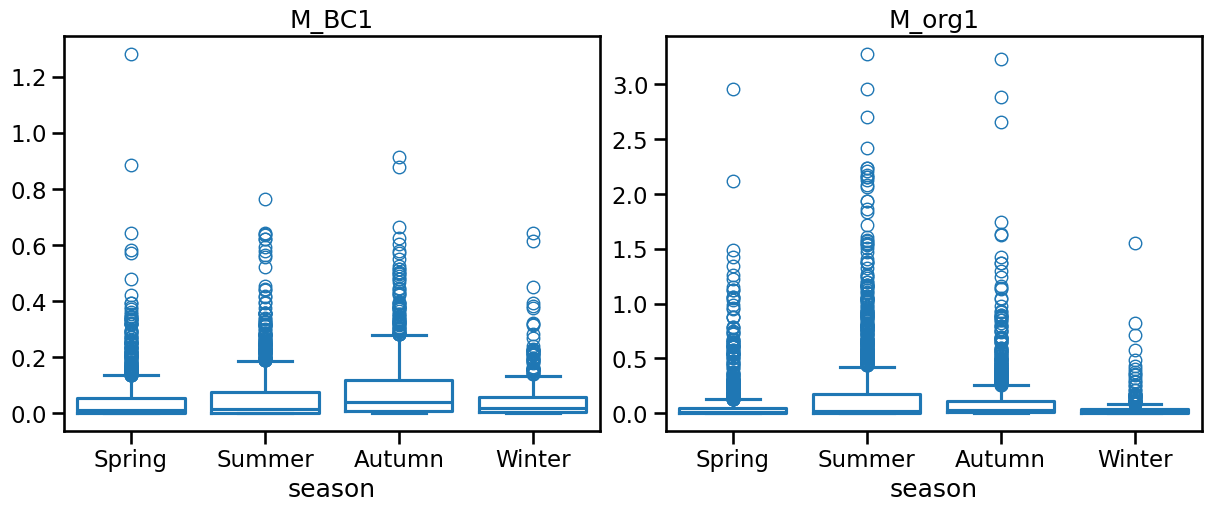

In [109]:
with sns.plotting_context("talk"):
    fig,axes = plt.subplots(ncols=2, nrows=1, figsize=(12,5), constrained_layout=True)

    sns.boxplot(x='season', y='M_BC1_median', data=mcmc_params_bc_org_size.loc[rhat_index_m5], fill=False, ax=axes[0])
    sns.boxplot(x='season', y='M_org1_median', data=mcmc_params_bc_org_size.loc[rhat_index_m5], fill=False, ax=axes[1])
    axes[0].set_title('M_BC1')
    axes[1].set_title('M_org1')
    axes[0].set_ylabel('')
    axes[1].set_ylabel('')
    axes[0].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])
    axes[1].set_xticklabels(['Spring', 'Summer', 'Autumn', 'Winter'])

In [110]:
# calculate CCN from mcmc results (uncomment last line to save, or load farther down)
from models import CCNmodel_m5

mcmc_results_m5 = pd.DataFrame({'datetime': mcmc_params_org_and_size['datetime']})

cols_to_add = [
    'NRMSE', 'predicted_CCN1', 'predicted_CCN2', 'inorg_density', 'Predicted_CCN',
    'f_org1', 'f_AS1', 'f_BC1', 'f_org2', 'f_AS2', 'f_BC2',
    'k1', 'k2', 'mass_aitken', 'mass_accumulation'
]

for col in cols_to_add:
    if col in ['predicted_CCN1', 'predicted_CCN2', 'Predicted_CCN']:
        mcmc_results_m5[col] = pd.Series([np.nan]*5, dtype='object')
    else:
        mcmc_results_m5[col] = np.nan

check_rows = [] #rows with mcmc output, but medians do not give valid CCN results.ss

all_cols_to_nan = mcmc_results_m5.columns.difference(['datetime'])

for ii in rhat_index_m5:

    # skip rows with NaN:
    if pd.isna(mcmc_params_org_and_size.iloc[ii]).any():
        mcmc_results_m5.loc[ii, all_cols_to_nan] = np.nan

    else:
        try:
            Extra = get_Extra(ii)
            model_data, initial_guesses, prior_params, response = load_data(ii)
            m = CCNmodel_m5(Extra, model_data, return_all=True)

            model_parameters = [mcmc_params_bc_org_size.iloc[ii]['M_BC1_median'], mcmc_params_bc_org_size.iloc[ii]['M_org1_median'], mcmc_params_bc_org_size.iloc[ii]['D1_median'], mcmc_params_bc_org_size.iloc[ii]['N1_median'], mcmc_params_bc_org_size.iloc[ii]['D2_median'], mcmc_params_bc_org_size.iloc[ii]['N2_median']]
            ccn1, ccn2, k1, k2, k_inorg1, k_inorg2, mass_frac_aitken, mass_frac_accumulation, total_ait_mass, total_acc_mass, total_mass,info_mass, NSD1_vec, NSD2_vec = m(model_parameters)

            nrmse = np.sqrt(np.mean((response - (ccn1+ccn2))**2)) / np.mean(response)

            mcmc_results_m5.at[ii, 'NRMSE'] = nrmse
            mcmc_results_m5.at[ii, 'predicted_CCN1'] = ccn1
            mcmc_results_m5.at[ii, 'predicted_CCN2'] = ccn2
            mcmc_results_m5.at[ii, 'inorg_density'] = Extra['rho_inorg']
            mcmc_results_m5.at[ii, 'Predicted_CCN'] = ccn1 + ccn2
            mcmc_results_m5.at[ii, 'f_org1'] = mass_frac_aitken[0]
            mcmc_results_m5.at[ii, 'f_AS1'] = mass_frac_aitken[2]
            mcmc_results_m5.at[ii, 'f_BC1'] = mass_frac_aitken[4]
            mcmc_results_m5.at[ii, 'f_org2'] = mass_frac_accumulation[0]
            mcmc_results_m5.at[ii, 'f_AS2'] = mass_frac_accumulation[2]
            mcmc_results_m5.at[ii, 'f_BC2'] = mass_frac_accumulation[4]
            mcmc_results_m5.at[ii, 'k1'] = k1
            mcmc_results_m5.at[ii, 'k2'] = k2
            mcmc_results_m5.at[ii, 'mass_aitken'] = total_ait_mass
            mcmc_results_m5.at[ii, 'mass_accumulation'] = total_acc_mass
            mcmc_results_m5.at[ii, 'tot_org_mass'] = info_mass['tot_org']
            mcmc_results_m5.at[ii, 'info_mass'] = info_mass

        except Exception as e:
            print(f"No model output for median parameters for row {ii}: {e}")
            mcmc_results_m5.loc[ii, all_cols_to_nan] = np.nan
            check_rows.append(ii)
            continue

No model output for median parameters for row 0: Incompatible indexer with Series
No model output for median parameters for row 34: cannot unpack non-iterable NoneType object
No model output for median parameters for row 109: cannot unpack non-iterable NoneType object
No model output for median parameters for row 146: cannot unpack non-iterable NoneType object
No model output for median parameters for row 243: cannot unpack non-iterable NoneType object
No model output for median parameters for row 274: cannot unpack non-iterable NoneType object
No model output for median parameters for row 294: cannot unpack non-iterable NoneType object
No model output for median parameters for row 363: cannot unpack non-iterable NoneType object
No model output for median parameters for row 368: cannot unpack non-iterable NoneType object
No model output for median parameters for row 460: cannot unpack non-iterable NoneType object
No model output for median parameters for row 461: cannot unpack non-iter

In [79]:
mcmc_results_m5 = pd.read_csv('../results/mcmc_results_m5_bc_and_sizeparams_filtered.csv')

In [80]:
mcmc_results_m5['season'] = pd.to_datetime(mcmc_results_m5['datetime']).apply(get_season)

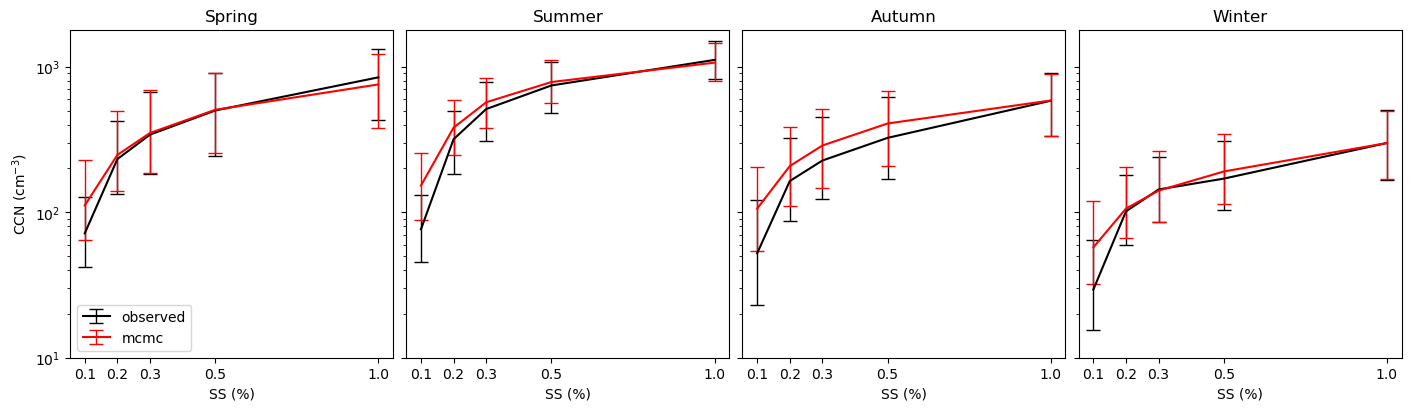

In [119]:
#plot CCN spectra:
nedmead_results['season'] = pd.to_datetime(nedmead_results['datetime']).apply(get_season)
observed_results['season'] = pd.to_datetime(observed_results['datetime']).apply(get_season)

seasonal_stats_mcmc = compute_seasonal_stats(mcmc_results_m5.loc[rhat_index_m5], 'Predicted_CCN', 'mcmc')
seasonal_stats_nedmead = compute_seasonal_stats(nedmead_results, 'Predicted_CCN', 'nedmead')
seasonal_stats_obs = compute_seasonal_stats(observed_results, 'CCN', 'observed')

# Combine all into one DataFrame
seasonal_stats_all = pd.concat([seasonal_stats_mcmc, seasonal_stats_obs], ignore_index=True)

plot_ccn_spectra(seasonal_stats_all, 'CCN (cm$^{-3}$)')

In [81]:
# get NRMSE for each SS:
merged = pd.concat(
    [mcmc_results_m5["Predicted_CCN"], observed_results["CCN"]],
    axis=1,
    join="inner"
)

# Drop rows where either column is NaN
merged = merged.dropna()

# Now unpack into arrays
arr1 = np.vstack(
    merged["Predicted_CCN"].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=" ")
    )
)
arr2 = np.vstack(merged["CCN"].values)

merged = merged.dropna()

# Now unpack into arrays
arr1 = np.vstack(
    merged["Predicted_CCN"].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=" ")
    )
)
arr2 = np.vstack(merged["CCN"].values)

# Function for NRMSE
def nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))   # RMSE per column
    denom = np.mean(y_true, axis=0)   # range per column
    return rmse / denom

# Compute NRMSE per column (5 values)
nrmse_values = nrmse(arr2,arr1)

# Take median across rows for each of the 5 positions
median_nrmse = np.median(nrmse_values)

print("NRMSE values per position:", np.round(nrmse_values, 4))
print("Median NRMSE:", median_nrmse)

NRMSE values per position: [0.7626 0.3978 0.4107 0.4413 0.2594]
Median NRMSE: 0.4107434837422624


Text(0, 0.5, 'KDE Density')

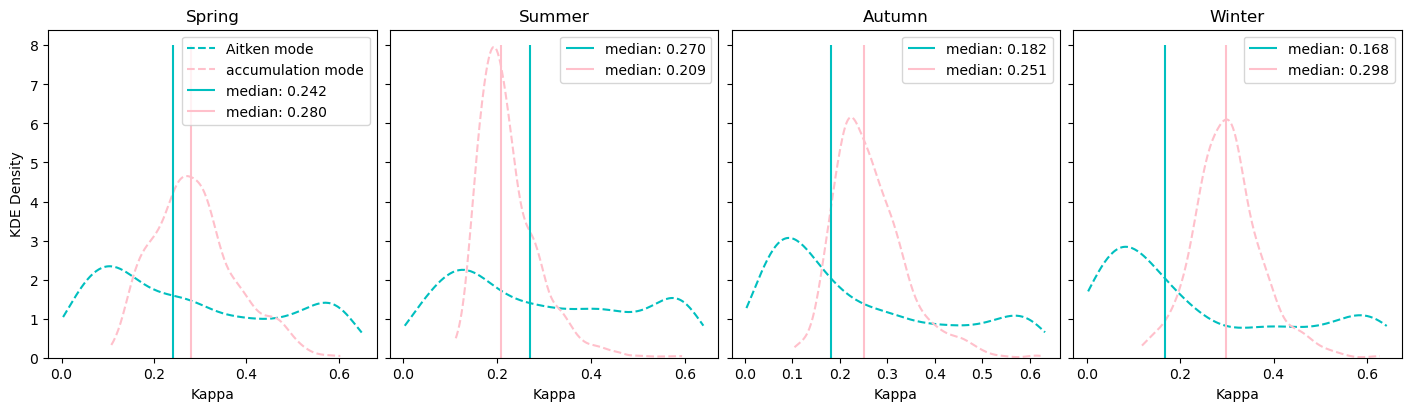

In [142]:
#plot kappa for each mode:
fig,axes = plt.subplots(ncols=4, nrows=1, figsize=(14,4), sharey=True, constrained_layout=True)
for season in range(4):
    ax = axes[season]

    group_mcmc = mcmc_results_m5.loc[rhat_index_m5].where((mcmc_results_m5['season'] == season))

    sns.kdeplot(group_mcmc['k1'].dropna(), ax=ax, label='Aitken mode', color='c', linewidth=1.5, linestyle='--', cut=0)
    sns.kdeplot(group_mcmc['k2'].dropna(), ax=ax, label='accumulation mode', color='pink', linewidth=1.5, linestyle='--', cut=0)

    median_val_k1 = group_mcmc['k1'].median()
    ax.vlines(median_val_k1, 0, 8, color='c', linestyle='-', label=f"median: {median_val_k1:.3f}")
    median_val_k2 = group_mcmc['k2'].median()
    ax.vlines(median_val_k2, 0, 8, color='pink', linestyle='-', label=f"median: {median_val_k2:.3f}")

    ax.set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
    ax.set_xlabel('Kappa')
    
    handles, labels = ax.get_legend_handles_labels()
    if season == 0:
        ax.legend(handles, labels)
    else:
        # Skip medians in other subplots
        ax.legend(handles[2:], labels[2:])
    

axes[0].set_ylabel('KDE Density')



In [161]:
axes.shape

(2, 4)

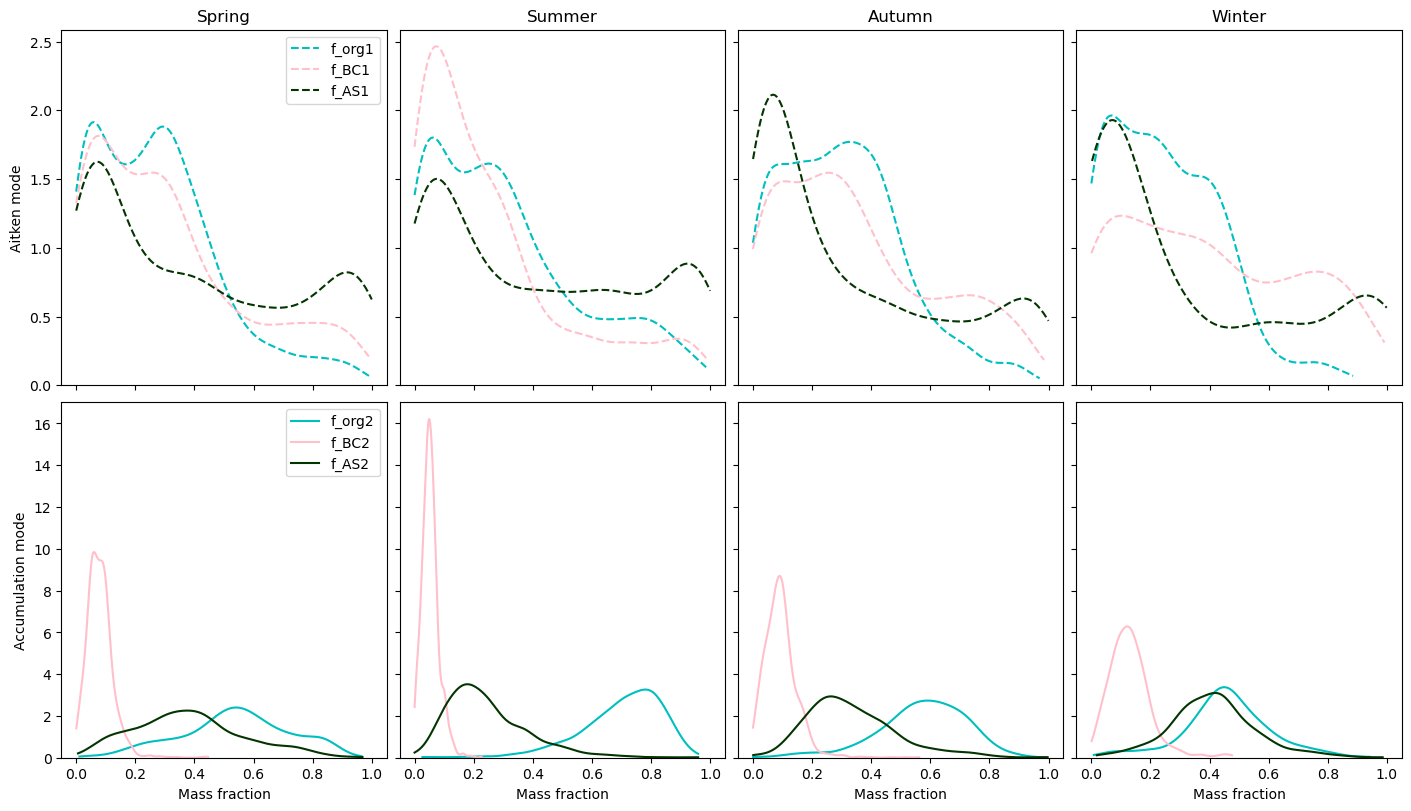

In [173]:
#plot mass fractions for each mode:
fig,axes = plt.subplots(ncols=4, nrows=2, figsize=(14,8), sharex=True, constrained_layout=True)
for row in axes:
    for ax in row[1:]:   # skip first in row
        ax.sharey(row[0])
        ax.tick_params(labelleft=False)  # hide y tick labels

for season in range(4):
    ax = axes[:,season]

    group_mcmc = mcmc_results_m5.loc[rhat_index_m5].where((mcmc_results_m5['season'] == season))

    sns.kdeplot(group_mcmc['f_org1'].dropna(), ax=ax[0], label='f_org1', color='c', linewidth=1.5, linestyle='--', cut=0)
    sns.kdeplot(group_mcmc['f_BC1'].dropna(), ax=ax[0], label='f_BC1', color='pink', linewidth=1.5, linestyle='--', cut=0)
    sns.kdeplot(group_mcmc['f_AS1'].dropna(), ax=ax[0], label='f_AS1', color='xkcd:dark green', linewidth=1.5, linestyle='--', cut=0)

    sns.kdeplot(group_mcmc['f_org2'].dropna(), ax=ax[1], label='f_org2', color='c', linewidth=1.5, cut=0)
    sns.kdeplot(group_mcmc['f_BC2'].dropna(), ax=ax[1], label='f_BC2', color='pink', linewidth=1.5, cut=0)
    sns.kdeplot(group_mcmc['f_AS2'].dropna(), ax=ax[1], label='f_AS2', color='xkcd:dark green', linewidth=1.5, cut=0)

    #median_val_k1 = group_mcmc['k1'].median()
    #ax.vlines(median_val_k1, 0, 8, color='c', linestyle='-', label=f"median: {median_val_k1:.3f}")
    #median_val_k2 = group_mcmc['k2'].median()
    #ax.vlines(median_val_k2, 0, 8, color='pink', linestyle='-', label=f"median: {median_val_k2:.3f}")

    ax[0].set_title(['Spring', 'Summer', 'Autumn', 'Winter'][season])
    ax[1].set_xlabel('Mass fraction')
    ax[0].set_ylabel('')
    ax[1].set_ylabel('')
    
    #handles, labels = ax.get_legend_handles_labels()
    #if season == 0:
    #    ax.legend(handles, labels)
    #else:
    #    # Skip medians in other subplots
    #    ax.legend(handles[2:], labels[2:])

axes[0,0].set_ylabel('Aitken mode')
axes[1,0].set_ylabel('Accumulation mode')
axes[0,0].legend()
axes[1,0].legend()


In [182]:
mcmc_results_m5['f_BC1'].median() 

np.float64(0.2592937666707539)

In [150]:
# save:
mcmc_params_bc_org_size.loc[not_converged, all_cols_to_nan] = np.nan
mcmc_params_bc_org_size.to_csv('../results/summary_m5_bc_and_sizeparams_filtered.csv')

mcmc_results_m5.loc[not_converged, all_cols_to_nan] = np.nan
mcmc_results_m5.to_csv('../results/mcmc_results_m5_bc_and_sizeparams_filtered.csv')